In [ ]:
test


# Win10 Cohort Discrimination Model

**Goal**: Determine whether features from an external Firefox telemetry table can separate
Win10→Win11 migrators (users who kept Firefox through an upgrade) from Win10 dropoffs
(users who disappeared from Firefox, presumably switching browser).

**Structure**:
- **Part 1** — Build a labelled analysis table in BigQuery by joining the external table to the migrator/dropoff cohorts via canonical client IDs and matching rows to the cohort reference date.
- **Part 2** — Load the analysis table, engineer features, train XGBoost, evaluate, and produce a go/no-go verdict. Part 2 is self-contained: it only needs the shared setup cells (imports, auth, config).

**Template usage**: Change `EXTERNAL_TABLE`, `CLIENT_ID_COL`, and `DATE_COL` in `# [config]`.
After running `# [inspect-schema]`, paste the output into Claude to generate `# [feature-prep]`.

## Setup (shared by Parts 1 and 2)

In [ ]:
# [imports]
import pandas as pd
import numpy as np
# loaded via --file


In [ ]:
# [file-added]
print("added via --file")


## Bulk Section
Added via import.

In [ ]:
# [bulk-cell-1]
x = 1
print(x)

In [ ]:
# [bulk-cell-2]
y = x + 1
print(y)

In [2]:
# [auth]
# Colab Enterprise: authentication is handled automatically via google.auth.default().
PROJECT = 'moz-fx-data-bq-data-science'

In [3]:
# [config]
CONFIG = {"test": True}


External table:  mozdata.firefox_desktop.baseline_active_users
Client ID col:   client_id
Date col:        submission_date
Feature cols:    26
Extra WHERE:     is_desktop
Analysis table:  moz-fx-data-bq-data-science.brwells.analysis_baseline_active_users_2026_03
Date window:     ±3 days  (2025-01-01 → 2026-02-01)
Train/val/test:  60% / 20% / 20%
Search pool:     top-7 SHAP features


In [4]:
# [bq-client]
# Lazy singleton BQ client — used in Part 1.
# Part 2 instantiates its own client inside load_bq.
_bq_client = None

def bq():
    global _bq_client
    if _bq_client is None:
        _bq_client = bigquery.Client(PROJECT)
    return _bq_client

---
## Part 1: Build Analysis Table

Joins the external table to the migrator/dropoff cohorts via canonical client IDs.
Each row in the output represents one user, labelled `1` (migrator) or `0` (dropoff),
with the data columns from the external table.

**Reference dates** (when `DATE_COL` is set):
- Migrators → `first_win11` (the day they were first seen on Win11)
- Dropoffs → `last_win10` (the last day they were seen on Win10)

Rows more than `DATE_WINDOW_DAYS` away from the reference date are dropped.
When multiple rows per user survive, the closest row is kept; ties go to the earlier date.

In [5]:
# [query-analysis-table]
# Builds the CREATE OR REPLACE TABLE SQL string.
# Handles both date-matched (DATE_COL set) and date-less (DATE_COL = None) tables.

# Build the SELECT expression for external feature columns.
# CLIENT_ID_COL and DATE_COL are always handled separately, so exclude them here.
_skip_cols = {CLIENT_ID_COL, DATE_COL} if DATE_COL is not None else {CLIENT_ID_COL}
if FEATURE_COLS is not None:
    _feature_select = ',\n    '.join(f'ext.{c}' for c in FEATURE_COLS if c not in _skip_cols)
else:
    _feature_select = 'ext.* EXCEPT (' + ', '.join(_skip_cols) + ')'

# Build the optional extra WHERE fragment.
_extra_where = f'\n  AND {EXTRA_WHERE}' if EXTRA_WHERE else ''

if DATE_COL is not None:
    _sql = f"""
CREATE OR REPLACE TABLE `{ANALYSIS_TABLE}`
OPTIONS (
  expiration_timestamp = TIMESTAMP(DATE_ADD(CURRENT_DATE(), INTERVAL 9 MONTH)),
  labels = [("year_month", "{TABLE_SUFFIX}")]
)
AS

WITH

-- 1. Map external client IDs to canonical IDs.
--    Two original client IDs may share a canonical ID (connected component in the ID graph).
--    Filter to the observation window before joining to keep the scan small.
mapped AS (
  SELECT
    m.canonical_id            AS canonical_client_id,
    ext.{DATE_COL}            AS row_date,
    {_feature_select}
  FROM `{EXTERNAL_TABLE}` ext
  INNER JOIN `{NODE_MAPPINGS}` m
    ON ext.{CLIENT_ID_COL} = m.node_id
  WHERE ext.{DATE_COL} BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'{_extra_where}
),

-- 2. Reference event date per canonical ID.
--    migrators: first date seen on Win11 (the transition moment).
--    dropoffs:  last date seen on Win10 (the departure moment).
ref AS (
  SELECT s.canonical_client_id, 1 AS label, s.first_win11 AS reference_date
  FROM `{USER_STATS}` s
  WHERE s.canonical_client_id IN (SELECT canonical_client_id FROM `{MIGRATORS_TABLE}`)
    AND s.first_win11 IS NOT NULL

  UNION ALL

  SELECT s.canonical_client_id, 0 AS label, s.last_win10 AS reference_date
  FROM `{USER_STATS}` s
  WHERE s.canonical_client_id IN (SELECT canonical_client_id FROM `{DROPOFFS_TABLE}`)
    AND s.last_win10 IS NOT NULL
),

-- 3. Join and compute the distance between each row's date and its reference date.
joined AS (
  SELECT
    ref.canonical_client_id,
    ref.reference_date,
    ref.label,
    mapped.row_date,
    ABS(DATE_DIFF(mapped.row_date, ref.reference_date, DAY)) AS date_distance,
    mapped.* EXCEPT (canonical_client_id, row_date)
  FROM mapped
  INNER JOIN ref USING (canonical_client_id)
),

-- 4. Drop rows outside the date window.
windowed AS (
  SELECT * FROM joined
  WHERE date_distance <= {DATE_WINDOW_DAYS}
),

-- 5. For each user keep only the row closest to their reference date.
--    Tie-break: prefer the earlier (past) row_date.
--    If ties remain after this (same distance, same row_date), dedup-check will catch them.
ranked AS (
  SELECT
    *,
    ROW_NUMBER() OVER (
      PARTITION BY canonical_client_id
      ORDER BY date_distance ASC, row_date ASC
    ) AS _rn
  FROM windowed
)

SELECT * EXCEPT (_rn, date_distance)
FROM ranked
WHERE _rn = 1
"""

else:
    # No date column — straightforward join.
    # If the same canonical_client_id has multiple rows in the external table,
    # dedup-check below will halt and ask you to resolve.
    _mapped_where = f'\n  WHERE {EXTRA_WHERE}' if EXTRA_WHERE else ''
    _sql = f"""
CREATE OR REPLACE TABLE `{ANALYSIS_TABLE}`
OPTIONS (
  expiration_timestamp = TIMESTAMP(DATE_ADD(CURRENT_DATE(), INTERVAL 9 MONTH)),
  labels = [("year_month", "{TABLE_SUFFIX}")]
)
AS

WITH

-- 1. Map external client IDs to canonical IDs.
mapped AS (
  SELECT
    m.canonical_id AS canonical_client_id,
    {_feature_select}
  FROM `{EXTERNAL_TABLE}` ext
  INNER JOIN `{NODE_MAPPINGS}` m
    ON ext.{CLIENT_ID_COL} = m.node_id{_mapped_where}
),

-- 2. Labels.
ref AS (
  SELECT canonical_client_id, 1 AS label FROM `{MIGRATORS_TABLE}`
  UNION ALL
  SELECT canonical_client_id, 0 AS label FROM `{DROPOFFS_TABLE}`
)

SELECT
  ref.canonical_client_id,
  ref.label,
  mapped.* EXCEPT (canonical_client_id)
FROM mapped
INNER JOIN ref USING (canonical_client_id)
"""

print(_sql)


CREATE OR REPLACE TABLE `moz-fx-data-bq-data-science.brwells.analysis_baseline_active_users_2026_03`
OPTIONS (
  expiration_timestamp = TIMESTAMP(DATE_ADD(CURRENT_DATE(), INTERVAL 9 MONTH)),
  labels = [("year_month", "2026_03")]
)
AS

WITH

-- 1. Map external client IDs to canonical IDs.
--    Two original client IDs may share a canonical ID (connected component in the ID graph).
--    Filter to the observation window before joining to keep the scan small.
mapped AS (
  SELECT
    m.canonical_id            AS canonical_client_id,
    ext.submission_date            AS row_date,
    ext.first_run_date,
    ext.durations,
    ext.days_since_desktop_active,
    ext.days_since_seen,
    ext.days_since_active,
    ext.days_since_created_profile,
    ext.app_channel,
    ext.isp,
    ext.geo_subdivision,
    ext.install_source,
    ext.browser_engagement_uri_count,
    ext.browser_engagement_active_ticks,
    ext.is_default_browser,
    ext.active_hours_sum,
    ext.startup_profile_selectio

In [6]:
# [write-analysis-bq]
print(f'Creating {ANALYSIS_TABLE} ...')
job = bq().query(_sql)
job.result()

tbl = bq().get_table(ANALYSIS_TABLE)
print(f'Done — {tbl.num_rows:,} rows  |  expires {tbl.expires}')

Creating moz-fx-data-bq-data-science.brwells.analysis_baseline_active_users_2026_03 ...
Done — 1,481,988 rows  |  expires 2026-12-13 08:00:00+00:00


In [ ]:
# [dedup-check]
# fixed version
result = df.groupby("profile_group_id").size()
print("OK")


In [ ]:
# [dedup-resolve]
# ─────────────────────────────────────────────────────────────────────────────
# ONLY needed if # [dedup-check] raised a RuntimeError.
#
# The expensive join has already run and the table is written.
# This cell defines a lightweight dedup SELECT over that table.
# Run this cell, then run # [write-deduped-bq] to overwrite the table.
#
# Uncomment ONE strategy. All strategies produce a SELECT that returns
# exactly one row per canonical_client_id.
# ─────────────────────────────────────────────────────────────────────────────

# STRATEGY 1 — Keep an arbitrary but stable row (add a tiebreaker column).
# Use when duplicate rows are near-identical and the choice doesn't matter.
# Replace `some_stable_column` with any column that produces a stable ordering.
#
# _dedup_select = f"""
#   SELECT * EXCEPT (_rn)
#   FROM (
#     SELECT *,
#       ROW_NUMBER() OVER (
#         PARTITION BY canonical_client_id
#         ORDER BY some_stable_column ASC
#       ) AS _rn
#     FROM `{ANALYSIS_TABLE}`
#   )
#   WHERE _rn = 1
# """

# STRATEGY 2 — Prefer a specific column value.
# Use when one variant of a row is more trustworthy than another.
# Example: prefer channel = 'release' over 'beta':
#
# _dedup_select = f"""
#   SELECT * EXCEPT (_rn)
#   FROM (
#     SELECT *,
#       ROW_NUMBER() OVER (
#         PARTITION BY canonical_client_id
#         ORDER BY IF(channel = 'release', 0, 1) ASC
#       ) AS _rn
#     FROM `{ANALYSIS_TABLE}`
#   )
#   WHERE _rn = 1
# """

# STRATEGY 3 — Aggregate duplicate rows into one.
# Use when duplicates are repeated measurements of the same user.
# Adapt the column list to match your schema.
#
# _dedup_select = f"""
#   SELECT
#     canonical_client_id,
#     label,
#     ANY_VALUE(reference_date)    AS reference_date,  -- or MIN/MAX
#     AVG(some_numeric_col)        AS some_numeric_col,
#     ANY_VALUE(some_string_col)   AS some_string_col
#   FROM `{ANALYSIS_TABLE}`
#   GROUP BY canonical_client_id, label
# """

raise NotImplementedError(
    'Uncomment one strategy above and remove this line, then run # [write-deduped-bq].'
)

In [ ]:
# [write-deduped-bq]
# ONLY run this if # [dedup-check] raised an error and you have filled in # [dedup-resolve].
# Overwrites ANALYSIS_TABLE with the deduped result. Does not re-run the join.

_dedup_sql = f"""
CREATE OR REPLACE TABLE `{ANALYSIS_TABLE}`
OPTIONS (
  expiration_timestamp = TIMESTAMP(DATE_ADD(CURRENT_DATE(), INTERVAL 9 MONTH)),
  labels = [("year_month", "{TABLE_SUFFIX}")]
)
AS
{_dedup_select}
"""

print(f'Overwriting {ANALYSIS_TABLE} with deduped result ...')
bq().query(_dedup_sql).result()

tbl = bq().get_table(ANALYSIS_TABLE)
print(f'Done — {tbl.num_rows:,} rows  |  expires {tbl.expires}')
print('Re-run # [dedup-check] to confirm no duplicates remain.')

NameError: name '_dedup_select' is not defined

# test by cell id
pass


In [ ]:
# [diag-pipeline]
# ─────────────────────────────────────────────────────────────────────────────
# Off by default (expensive: re-scans the external table).
# Reports per-label user counts at each stage of the analysis-table pipeline:
#   step0  cohort sizes (before any join)
#   step1  users found in external table within the date range
#   step2  users surviving the ±DATE_WINDOW_DAYS proximity filter
#   step3  final analysis table (after dedup)
#
# Purpose: verify that the join is not introducing label imbalance beyond what
# the external table's own coverage naturally explains.
# ─────────────────────────────────────────────────────────────────────────────
RUN_PIPELINE_DIAG = True

if RUN_PIPELINE_DIAG:
    _diag_pipeline_sql = f"""
WITH

ref AS (
  SELECT s.canonical_client_id, 1 AS label, s.first_win11 AS reference_date
  FROM `{USER_STATS}` s
  WHERE s.canonical_client_id IN (SELECT canonical_client_id FROM `{MIGRATORS_TABLE}`)
    AND s.first_win11 IS NOT NULL
  UNION ALL
  SELECT s.canonical_client_id, 0 AS label, s.last_win10 AS reference_date
  FROM `{USER_STATS}` s
  WHERE s.canonical_client_id IN (SELECT canonical_client_id FROM `{DROPOFFS_TABLE}`)
    AND s.last_win10 IS NOT NULL
),

mapped AS (
  SELECT
    m.canonical_id     AS canonical_client_id,
    ext.{DATE_COL}     AS row_date
  FROM `{EXTERNAL_TABLE}` ext
  INNER JOIN `{NODE_MAPPINGS}` m
    ON ext.{CLIENT_ID_COL} = m.node_id
  WHERE ext.{DATE_COL} BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'{_extra_where}
),

joined AS (
  SELECT
    ref.canonical_client_id,
    ref.label,
    ref.reference_date,
    mapped.row_date,
    ABS(DATE_DIFF(mapped.row_date, ref.reference_date, DAY)) AS date_distance
  FROM mapped
  INNER JOIN ref USING (canonical_client_id)
),

windowed AS (
  SELECT * FROM joined
  WHERE date_distance <= {DATE_WINDOW_DAYS}
),

step0 AS (
  SELECT 'step0_cohort_size'          AS step, label, COUNT(DISTINCT canonical_client_id) AS n
  FROM ref      GROUP BY label
),
step1 AS (
  SELECT 'step1_in_external_table'    AS step, label, COUNT(DISTINCT canonical_client_id) AS n
  FROM joined   GROUP BY label
),
step2 AS (
  SELECT 'step2_after_date_proximity' AS step, label, COUNT(DISTINCT canonical_client_id) AS n
  FROM windowed GROUP BY label
),
step3 AS (
  SELECT 'step3_final_analysis_table' AS step, label, COUNT(*) AS n
  FROM `{ANALYSIS_TABLE}`             GROUP BY label
)

SELECT * FROM step0
UNION ALL SELECT * FROM step1
UNION ALL SELECT * FROM step2
UNION ALL SELECT * FROM step3
ORDER BY step, label
"""

    df_pipeline = bq().query(_diag_pipeline_sql).to_dataframe()
    df_pipeline['label_name'] = df_pipeline['label'].map({1: 'migrators', 0: 'dropoffs'})

    pivot = (
        df_pipeline
        .pivot_table(index='step', columns='label_name', values='n', aggfunc='first')
        [['migrators', 'dropoffs']]
    )
    pivot['ratio_d:m']           = pivot['dropoffs']  / pivot['migrators']
    pivot['migrators_%_of_prev'] = pivot['migrators'] / pivot['migrators'].shift(1)
    pivot['dropoffs_%_of_prev']  = pivot['dropoffs']  / pivot['dropoffs'].shift(1)

    display_df = pivot.copy()
    display_df['migrators']          = display_df['migrators'].map('{:,.0f}'.format)
    display_df['dropoffs']           = display_df['dropoffs'].map('{:,.0f}'.format)
    display_df['ratio_d:m']          = display_df['ratio_d:m'].map('{:.2f}'.format)
    display_df['migrators_%_of_prev'] = display_df['migrators_%_of_prev'].map(lambda x: f'{x:.1%}' if pd.notna(x) else '—')
    display_df['dropoffs_%_of_prev']  = display_df['dropoffs_%_of_prev'].map(lambda x: f'{x:.1%}' if pd.notna(x) else '—')
    print(display_df.to_string())

label_name                  migrators   dropoffs ratio_d:m migrators_%_of_prev dropoffs_%_of_prev
step                                                                                             
step0_cohort_size           1,038,762  4,466,636      4.30                   —                  —
step1_in_external_table       741,774    791,026      1.07               71.4%              17.7%
step2_after_date_proximity    739,764    742,224      1.00               99.7%              93.8%
step3_final_analysis_table    739,764    742,224      1.00              100.0%             100.0%


In [ ]:
# [diag-reference-dates]
# ─────────────────────────────────────────────────────────────────────────────
# Off by default (moderately expensive: scans USER_STATS + ANALYSIS_TABLE).
# For each label, shows the month-by-month distribution of reference dates
# (first_win11 for migrators, last_win10 for dropoffs) for:
#   - all  : every member of the cohort
#   - matched: those that successfully joined into the analysis table
# together with a per-month match rate.
#
# Purpose: detect whether match rate varies systematically with time period,
# e.g. whether recent events match better than older ones, or vice-versa.
# ─────────────────────────────────────────────────────────────────────────────
RUN_DATE_DIAG = True

if RUN_DATE_DIAG:
    _date_diag_sql = f"""
WITH

all_users AS (
  SELECT s.canonical_client_id, 1 AS label, s.first_win11 AS reference_date, 'all' AS grp
  FROM `{USER_STATS}` s
  WHERE s.canonical_client_id IN (SELECT canonical_client_id FROM `{MIGRATORS_TABLE}`)
    AND s.first_win11 IS NOT NULL

  UNION ALL

  SELECT s.canonical_client_id, 0 AS label, s.last_win10 AS reference_date, 'all' AS grp
  FROM `{USER_STATS}` s
  WHERE s.canonical_client_id IN (SELECT canonical_client_id FROM `{DROPOFFS_TABLE}`)
    AND s.last_win10 IS NOT NULL
),

matched_users AS (
  SELECT canonical_client_id, label, reference_date, 'matched' AS grp
  FROM `{ANALYSIS_TABLE}`
)

SELECT
  label,
  grp,
  FORMAT_DATE('%Y-%m', reference_date) AS month,
  COUNT(*) AS n_users
FROM (
  SELECT * FROM all_users
  UNION ALL
  SELECT * FROM matched_users
)
GROUP BY label, grp, month
ORDER BY label DESC, month, grp
"""

    df_dates = bq().query(_date_diag_sql).to_dataframe()
    df_dates['label_name'] = df_dates['label'].map({1: 'migrators', 0: 'dropoffs'})

    for lbl, grp in df_dates.groupby('label_name', sort=False):
        pivot = (
            grp
            .pivot_table(index='month', columns='grp', values='n_users', fill_value=0)
            .reindex(columns=['all', 'matched'])
        )
        pivot['match_rate'] = (pivot['matched'] / pivot['all']).map('{:.1%}'.format)
        print(f'\n=== {lbl} (reference date = {"first_win11" if lbl == "migrators" else "last_win10"}) ===')
        print(pivot.to_string())


=== migrators (reference date = first_win11) ===
grp           all  matched match_rate
month                                
2025-01   99765.0  95843.0      96.1%
2025-02   78519.0  63982.0      81.5%
2025-03   71026.0  54771.0      77.1%
2025-04   65120.0  48595.0      74.6%
2025-05   64440.0  46611.0      72.3%
2025-06   63637.0  45048.0      70.8%
2025-07   70841.0  50435.0      71.2%
2025-08   83013.0  56879.0      68.5%
2025-09  107968.0  69016.0      63.9%
2025-10  167816.0  99536.0      59.3%
2025-11   87450.0  56103.0      64.2%
2025-12   68275.0  46102.0      67.5%
2026-01   10892.0   6843.0      62.8%

=== dropoffs (reference date = last_win10) ===
grp           all   matched match_rate
month                                 
2025-01  378991.0      17.0       0.0%
2025-02  278578.0   18747.0       6.7%
2025-03  278905.0   36402.0      13.1%
2025-04  266913.0   41448.0      15.5%
2025-05  281418.0   48762.0      17.3%
2025-06  287407.0   52528.0      18.3%
2025-07  315032.0   

---
## Part 2: Discrimination Model

Self-contained: only requires the shared setup cells (imports, auth, config).
Does **not** depend on any Part 1 variables beyond those defined in `# [config]`.

**Workflow**:
1. Load the analysis table
2. Inspect schema → paste output into Claude → fill in `# [feature-prep]`
3. Train XGBoost
4. Evaluate (AUC, confusion matrix)
5. SHAP feature importance with direction
6. Shallow decision tree on top features (interpretable rules)
7. Go / weak signal / no-signal verdict

In [ ]:
# [load-features]
# Self-contained load: defines its own load_bq helper so Part 2 runs independently.

def load_bq(query, cache_path, force_refresh=False):
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_refresh:
        print(f'Loading from cache: {cache_path}')
        return pd.read_parquet(cache_path)
    print('Querying BigQuery...')
    client = bigquery.Client(PROJECT)
    df = client.query(query).to_dataframe()
    df.to_parquet(cache_path)
    print(f'Cached to {cache_path}')
    return df

_cache = CACHE_DIR / f'analysis_{ANALYSIS_TABLE.split(".")[-1]}.parquet'
df_raw = load_bq(f'SELECT * FROM `{ANALYSIS_TABLE}`', _cache, force_refresh=True)

print(f'Loaded {len(df_raw):,} rows x {df_raw.shape[1]} columns')
print()
print('Label balance:')
print(df_raw['label'].value_counts().rename({1: 'Migrators', 0: 'Churn'}).to_string())

Querying BigQuery...
Cached to data/cache/analysis_analysis_baseline_active_users_2026_03.parquet
Loaded 1,481,988 rows x 30 columns

Label balance:
label
Churn        742224
Migrators    739764


## Validation Section


In [ ]:
# [validate-load]
assert df is not None


In [17]:
# [inspect-schema]
# Run this cell, then paste the output into Claude with the prompt:
#   "Generate the # [feature-prep] cell for this schema."
# Claude will produce a hard-coded feature engineering block tailored to these columns.

print('=== dtypes ===')
print(df_raw.dtypes.to_string())
print()

print('=== null counts ===')
_nulls = df_raw.isnull().sum()
_nulls = _nulls[_nulls > 0]
print(_nulls.to_string() if len(_nulls) > 0 else 'No nulls.')
print()

print('=== sample rows ===')
print(df_raw.head(3).to_string())
print()

# Value counts for low-cardinality object columns
_obj_cols = df_raw.select_dtypes('object').columns.difference(['canonical_client_id'])
for _col in _obj_cols:
    _n = df_raw[_col].nunique()
    if _n <= 50:
        print(f'--- {_col}  ({_n} unique values) ---')
        print(df_raw[_col].value_counts(dropna=False).head(20).to_string())
        print()

=== dtypes ===
canonical_client_id                        object
reference_date                             object
label                                       Int64
row_date                                   object
first_run_date                             object
durations                                   Int64
days_since_desktop_active                   Int64
days_since_seen                             Int64
days_since_active                           Int64
days_since_created_profile                  Int64
app_channel                                object
isp                                        object
geo_subdivision                            object
install_source                             object
browser_engagement_uri_count                Int64
browser_engagement_active_ticks             Int64
is_default_browser                        boolean
active_hours_sum                          float64
startup_profile_selection_reason_first     object
app_version                        

### Feature preparation

The cell below is a **template placeholder**. Run `# [inspect-schema]`, paste the output
into Claude, and ask it to generate `# [feature-prep]` for the specific schema.

The cell must produce:
- `X` — `pd.DataFrame` of numeric features, no nulls, dtype `float32`
- `y` — `pd.Series` of int labels (`1` = migrator, `0` = dropoff)
- `feature_names` — `list[str]` matching `X.columns`

In [18]:
# [feature-prep]
df = df_raw.copy()
X_parts = []

_SENTINEL_DAYS = 9999  # fill for unknown elapsed-day columns

# ── Date: first_run_date → days elapsed before reference_date ─────────────────
_ref_dt       = pd.to_datetime(df['reference_date'])
_first_run_dt = pd.to_datetime(df['first_run_date'], errors='coerce')  # coerce out-of-range typos (e.g. 2921) → NaT → sentinel
df['days_since_first_run'] = (
    (_ref_dt - _first_run_dt).dt.days.clip(lower=0).fillna(_SENTINEL_DAYS)
)
X_parts.append(df[['days_since_first_run']].astype('float32'))

# ── Numeric: passthrough / sentinel-fill for nulls ────────────────────────────
X_parts.append(
    df[['days_since_seen', 'first_seen_year']].astype('float32')
)
X_parts.append(
    df[['days_since_desktop_active', 'days_since_active', 'days_since_created_profile']]
    .fillna(_SENTINEL_DAYS)
    .astype('float32')
)

# ── Numeric: log-transform right-skewed counts ────────────────────────────────
X_parts.append(
    np.log1p(
        df[['durations', 'browser_engagement_uri_count',
            'browser_engagement_active_ticks', 'active_hours_sum']]
        .astype('float64')
    )
    .rename(columns=lambda c: f'log_{c}')
    .astype('float32')
)

# ── Boolean: no-null columns ──────────────────────────────────────────────────
X_parts.append(
    df[['is_daily_user', 'is_weekly_user', 'is_monthly_user']]
    .astype('boolean').astype('float32')
)

# ── Boolean: is_default_browser — 229k nulls → sentinel -1 (unknown) ─────────
df['is_default_browser_f'] = (
    df['is_default_browser'].astype('object')
    .map({True: 1.0, False: 0.0, pd.NA: -1.0, None: -1.0})
    .fillna(-1.0)
    .astype('float32')
)
X_parts.append(df[['is_default_browser_f']])

# ── Binary derived: distribution_id present ───────────────────────────────────
df['has_distribution_id'] = df['distribution_id'].notna().astype('float32')
X_parts.append(df[['has_distribution_id']])

# ── Low-cardinality categoricals: one-hot ────────────────────────────────────

# app_channel — normalize garbage values to 'other', then one-hot
_known_channels = {'release', 'esr', 'beta', 'aurora', 'nightly'}
df['app_channel_norm'] = (
    df['app_channel'].fillna('unknown').str.strip().str.lower()
    .map(lambda x: x if x in _known_channels else 'other')
)
X_parts.append(pd.get_dummies(df['app_channel_norm'], prefix='app_channel').astype('float32'))

# channel — already clean
_known_ch = {'release', 'esr', 'beta', 'aurora', 'nightly'}
df['channel_norm'] = (
    df['channel'].fillna('unknown').str.lower()
    .map(lambda x: x if x in _known_ch else 'other')
)
X_parts.append(pd.get_dummies(df['channel_norm'], prefix='channel').astype('float32'))

# distribution_id_source — glean / legacy / unknown
X_parts.append(
    pd.get_dummies(df['distribution_id_source'].fillna('unknown'), prefix='dist_src')
    .astype('float32')
)

# activity_segment
X_parts.append(
    pd.get_dummies(df['activity_segment'].fillna('unknown'), prefix='activity_seg')
    .astype('float32')
)

# startup_profile_selection_reason_first — 64% null → 'unknown' class
X_parts.append(
    pd.get_dummies(
        df['startup_profile_selection_reason_first'].fillna('unknown'),
        prefix='startup'
    ).astype('float32')
)

# ── High-cardinality categoricals: top-20 + 'other' one-hot ──────────────────

# app_version — top-20 + 'other' (preferred over app_version_major/minor which are redundant)
_top_versions = df['app_version'].value_counts().head(20).index
df['app_version_grp'] = df['app_version'].where(df['app_version'].isin(_top_versions), other='other').fillna('other')
X_parts.append(pd.get_dummies(df['app_version_grp'], prefix='app_version').astype('float32'))

# for _col, _prefix in [('country', 'country'), ('locale', 'locale')]:
#     _top = df[_col].value_counts().head(20).index
#     df[f'{_col}_grp'] = df[_col].where(df[_col].isin(_top), other='other').fillna('other')
#     X_parts.append(pd.get_dummies(df[f'{_col}_grp'], prefix=_prefix).astype('float32'))

# ── Dropped columns ───────────────────────────────────────────────────────────
# install_source      — 100% null
# app_version_major   — redundant with app_version
# app_version_minor   — redundant with app_version
# isp                 — high cardinality, noisy
# geo_subdivision     — high cardinality, 18% null
# distribution_id     — captured via has_distribution_id

# ── Assemble ──────────────────────────────────────────────────────────────────
X = pd.concat(X_parts, axis=1).fillna(0.0)
y = df['label'].astype(int)
feature_names = X.columns.tolist()

print(f'Feature matrix: {X.shape}  migrators={y.sum():,}  dropoffs={(y==0).sum():,}')
assert X.isnull().sum().sum() == 0, 'Nulls remain in X'
assert X.dtypes.eq('float32').all(), 'Non-float32 columns in X'
print(f'Features ({len(feature_names)}): {feature_names[:8]} ... {feature_names[-3:]}')

Feature matrix: (1481988, 67)  migrators=739,764  dropoffs=742,224
Features (67): ['days_since_first_run', 'days_since_seen', 'first_seen_year', 'days_since_desktop_active', 'days_since_active', 'days_since_created_profile', 'log_durations', 'log_browser_engagement_uri_count'] ... ['app_version_146.0', 'app_version_146.0.1', 'app_version_other']


In [19]:
# [train-xgb]
# Three-way split: train (fit) / val (early stopping) / test (final evaluation).
# Using the test set for early stopping would leak test data into training and
# inflate the reported AUC.
_val_frac = VAL_SIZE / (1 - TEST_SIZE)   # val as a fraction of (train + val)

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=_val_frac, random_state=RANDOM_STATE, stratify=y_tmp
)

_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Split  — train: {len(y_train):,}  val: {len(y_val):,}  test: {len(y_test):,}')
print(f'scale_pos_weight = {_scale_pos_weight:.2f}  '
      f'(train: {(y_train==1).sum():,} migrators  {(y_train==0).sum():,} dropoffs)')

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=_scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f'Best iteration: {xgb_model.best_iteration}')
print(f'Best val AUC:   {xgb_model.best_score:.4f}')


Split  — train: 889,192  val: 296,398  test: 296,398
scale_pos_weight = 1.00  (train: 443,858 migrators  445,334 dropoffs)
Best iteration: 299
Best val AUC:   0.8851


In [ ]:
# [feature-labels]
# Human-readable labels for every model feature, consumed by pdp-analysis,
# ice-analysis, and feature-histograms.
#
# feat_labels[name] = {
#   'title'   : str   — plot panel title
#   'xlabel'  : str   — x-axis label (log features strip the "log" indicator)
#   'is_log'  : bool  — feature is log1p-transformed
#   'is_cat'  : bool  — feature is binary / one-hot categorical
#   'tick_map': dict  — {raw_value: label_str} for categorical tick overrides
#   'tick_fmt': fn    — callable(x) -> str for log-scale tick formatting
# }

import re
from matplotlib.ticker import FuncFormatter

# Categorical prefixes and their human names (order matters — longer first to avoid prefix conflicts)
_CAT_PREFIXES = [
    ('app_channel',  'App channel'),
    ('app_version',  'App version'),
    ('activity_seg', 'Activity segment'),
    ('dist_src',     'Distribution source'),
    ('startup',      'Startup reason'),
    ('channel',      'Channel'),
]

# Explicit overrides for features that don't parse cleanly
_EXPLICIT_LABELS = {
    'is_default_browser_f': {
        'title':    'Is default browser',
        'xlabel':   'Is default browser',
        'is_log':   False,
        'is_cat':   True,
        'tick_map': {-1.0: 'Unknown', 0.0: 'False', 1.0: 'True'},
        'tick_fmt': None,
    },
}

def _humanize(snake):
    """snake_case → Title Case words."""
    return re.sub(r'_+', ' ', snake).strip().title()

def _fmt_log_tick(x):
    """Format an expm1(x) value with K/M suffixes to keep tick labels short."""
    v = np.expm1(x)
    if v >= 1e6:
        return f'{v/1e6:.1f}M'
    if v >= 1e3:
        return f'{v/1e3:.1f}K'
    return f'{v:.3g}'

def _parse_feature(name):
    if name in _EXPLICIT_LABELS:
        return _EXPLICIT_LABELS[name]

    is_log = name.startswith('log_')
    base   = name[4:] if is_log else name

    # One-hot categoricals: match known prefix + '_'
    for prefix, human_prefix in _CAT_PREFIXES:
        if base.startswith(prefix + '_'):
            value = base[len(prefix) + 1:]
            title = f'{human_prefix}: {value}'
            return {
                'title': title, 'xlabel': title,
                'is_log': False, 'is_cat': True,
                'tick_map': {0.0: 'False', 1.0: 'True'}, 'tick_fmt': None,
            }

    # Boolean / binary heuristic (is_*, has_*)
    if base.startswith('is_') or base.startswith('has_'):
        human = _humanize(base)
        return {
            'title': human, 'xlabel': human,
            'is_log': False, 'is_cat': True,
            'tick_map': {0.0: 'False', 1.0: 'True'}, 'tick_fmt': None,
        }

    # Numeric — possibly log1p-transformed
    human = _humanize(base)
    if is_log:
        return {
            'title':    f'{human} (log-x)',
            'xlabel':   human,
            'is_log':   True,
            'is_cat':   False,
            'tick_map': None,
            'tick_fmt': _fmt_log_tick,
        }
    return {
        'title':    human,
        'xlabel':   human,
        'is_log':   False,
        'is_cat':   False,
        'tick_map': None,
        'tick_fmt': None,
    }

feat_labels = {name: _parse_feature(name) for name in feature_names}

# ── Print for human review ────────────────────────────────────────────────────
_W = (46, 38, 34, 9)
_hdr = (
    f'{"Feature":<{_W[0]}}  {"Title":<{_W[1]}}  '
    f'{"X-label":<{_W[2]}}  {"Type":<{_W[3]}}  Tick overrides'
)
print(_hdr)
print('─' * len(_hdr))
for _fname, _lbl in feat_labels.items():
    _type  = 'log' if _lbl['is_log'] else ('cat/bool' if _lbl['is_cat'] else 'numeric')
    _ticks = (
        ', '.join(f'{k}→{v}' for k, v in _lbl['tick_map'].items())
        if _lbl['tick_map']
        else ('log-fmt: expm1+K/M' if _lbl['tick_fmt'] else '—')
    )
    print(
        f'{_fname:<{_W[0]}}  {_lbl["title"]:<{_W[1]}}  '
        f'{_lbl["xlabel"]:<{_W[2]}}  {_type:<{_W[3]}}  {_ticks}'
    )

Feature                                         Title                                   X-label                             Type       Tick overrides
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
days_since_first_run                            Days Since First Run                    Days Since First Run                numeric    —
days_since_seen                                 Days Since Seen                         Days Since Seen                     numeric    —
first_seen_year                                 First Seen Year                         First Seen Year                     numeric    —
days_since_desktop_active                       Days Since Desktop Active               Days Since Desktop Active           numeric    —
days_since_active                               Days Since Active                       Days Since Active                   numeric    —
days_since_crea

Test AUC: 0.8844

              precision    recall  f1-score   support

       Churn       0.78      0.84      0.81    148445
   Migrators       0.83      0.76      0.79    147953

    accuracy                           0.80    296398
   macro avg       0.80      0.80      0.80    296398
weighted avg       0.80      0.80      0.80    296398



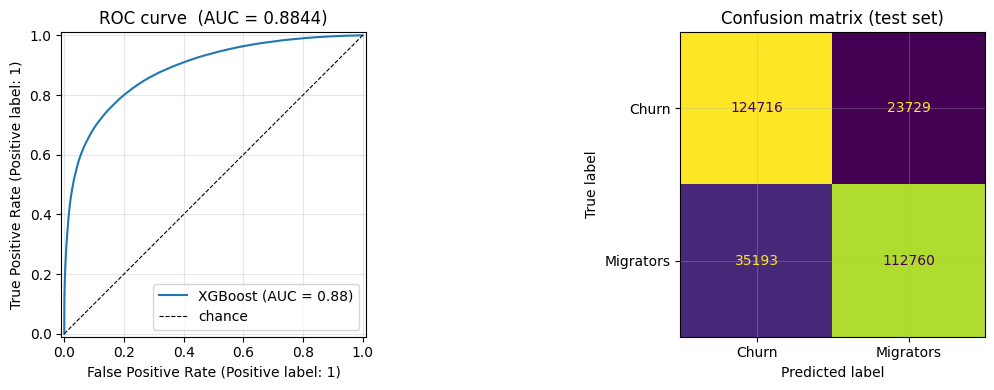

In [ ]:
# [eval-model]
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

_full_model_auc = roc_auc_score(y_test, y_prob)
print(f'Test AUC: {_full_model_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Churn', 'Migrators']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name='XGBoost')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8, label='chance')
axes[0].set_title(f'ROC curve  (AUC = {_full_model_auc:.4f})')
axes[0].legend()

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Churn', 'Migrators']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion matrix (test set)')

plt.tight_layout()
plt.show()

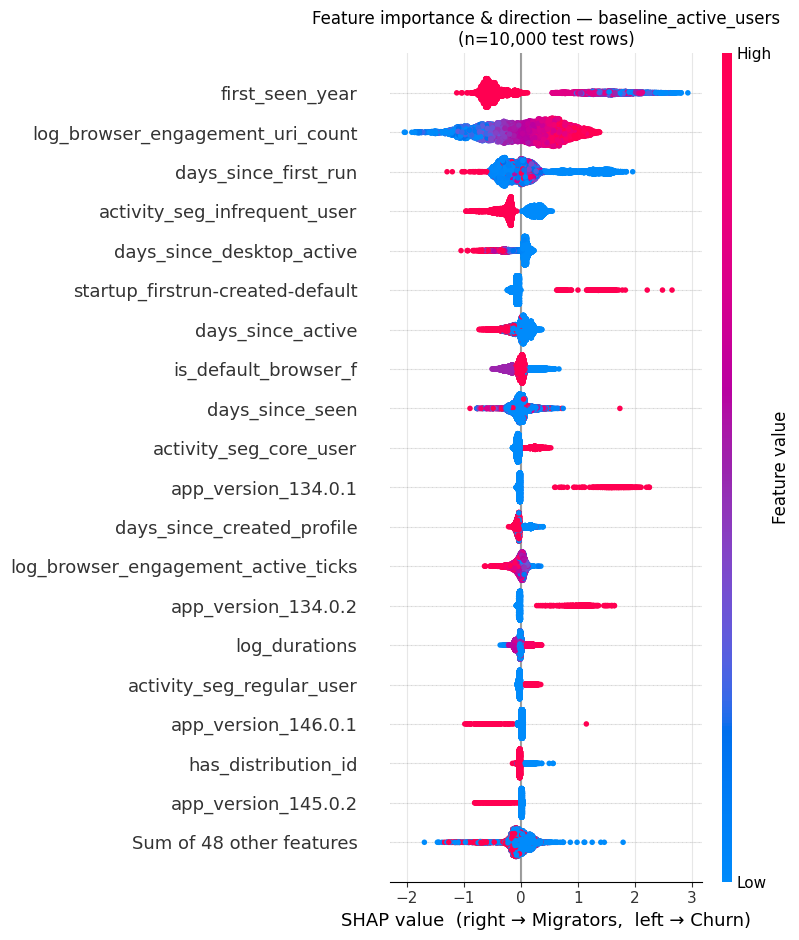

Top 10 features by mean |SHAP|:
first_seen_year                     0.8021
log_browser_engagement_uri_count    0.5447
days_since_first_run                0.3599
activity_seg_infrequent_user        0.2764
days_since_desktop_active           0.1363
startup_firstrun-created-default    0.1347
days_since_active                   0.1229
is_default_browser_f                0.1151
days_since_seen                     0.0987
activity_seg_core_user              0.0950


In [ ]:
# [shap-analysis]
# SHAP beeswarm: each dot is one test-set observation.
#   Colour = feature value (red = high, blue = low)
#   X-axis = SHAP value: right (positive) → pushes toward Migrators
#                        left  (negative) → pushes toward Churn
# Example read-out: "Country=US dots cluster on the right → US users migrate more."
#
# We sample the test set for speed (SHAP is O(n x tree_depth)).

import builtins

_N_SHAP = min(10_000, len(X_test))
_rng    = np.random.default_rng(RANDOM_STATE)
_idx    = _rng.choice(len(X_test), _N_SHAP, replace=False)

_X_shap = X_test.iloc[_idx] if hasattr(X_test, 'iloc') else X_test[_idx]

# Workaround: XGBoost >=1.6 stores base_score as '[5E-1]' and SHAP passes it
# directly to float(), which fails. Instance-patching save_config() on the Booster
# doesn't intercept the call (XGBoost accesses the C handle directly in some versions).
# Patching builtins.float to strip brackets is the most reliable fix: it intercepts
# the exact failing call regardless of how SHAP reads the config internally.
_orig_float = builtins.float

def _bracket_tolerant_float(x):
    if isinstance(x, str):
        x = x.strip('[]')
    return _orig_float(x)

builtins.float = _bracket_tolerant_float
try:
    _explainer = shap.TreeExplainer(xgb_model)
finally:
    builtins.float = _orig_float

_shap_values = _explainer(_X_shap)

plt.figure(figsize=(10, max(4, min(len(feature_names), 20) * 0.38)))
shap.plots.beeswarm(_shap_values, max_display=20, show=False)
plt.gca().set_xlabel('SHAP value  (right → Migrators,  left → Churn)')
plt.title(
    f'Feature importance & direction — {EXTERNAL_TABLE.split(".")[-1]}\n'
    f'(n={_N_SHAP:,} test rows)'
)
plt.tight_layout()
plt.show()

# Rank features by mean |SHAP| — used by decision-tree cell
_mean_abs_shap  = np.abs(_shap_values.values).mean(axis=0)
_shap_importance = pd.Series(_mean_abs_shap, index=feature_names).sort_values(ascending=False)

print(f'Top {TOP_N_FEATURES} features by mean |SHAP|:')
print(_shap_importance.head(TOP_N_FEATURES).round(4).to_string())

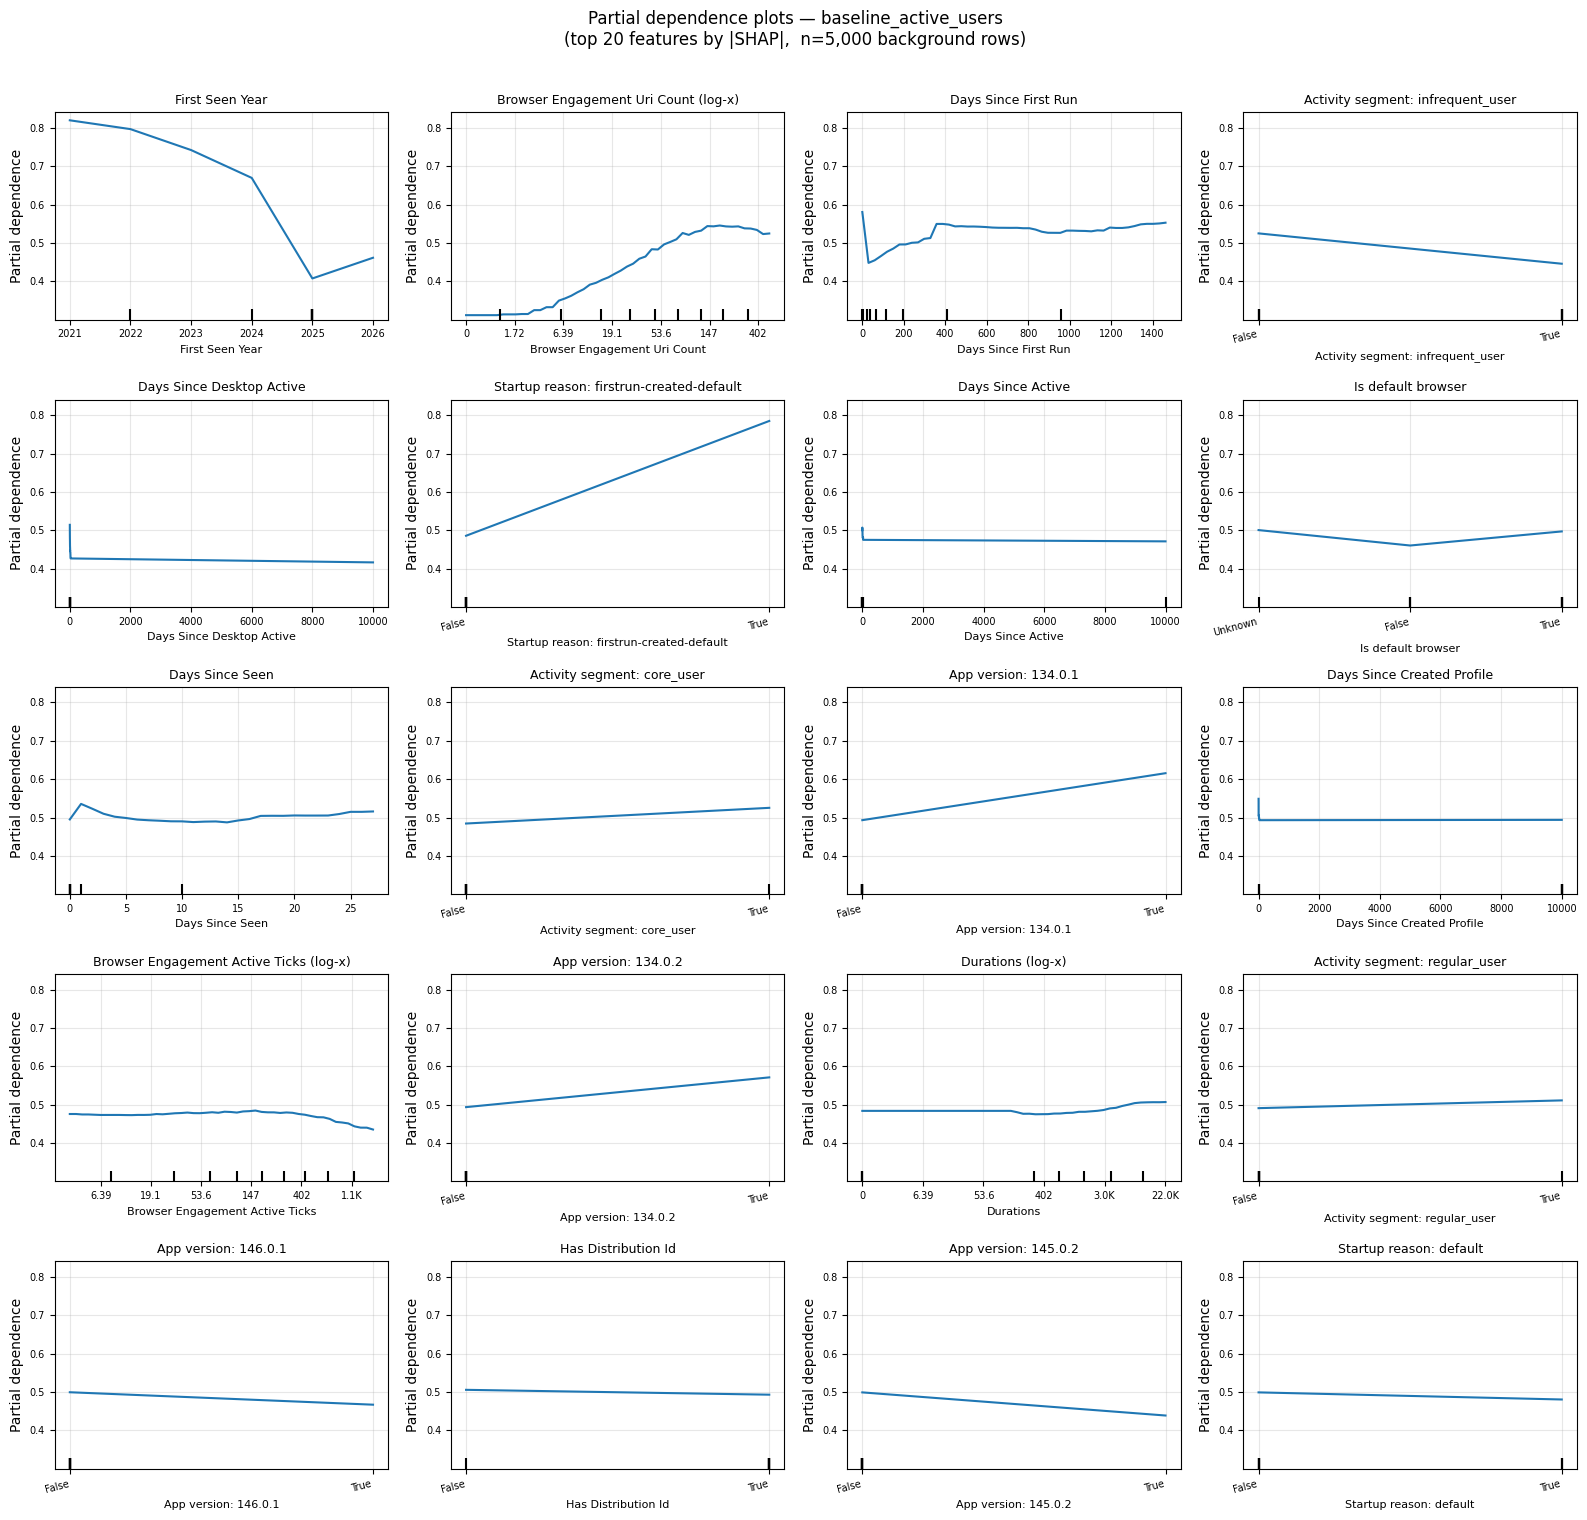

In [ ]:
# [pdp-analysis]
# Partial dependence plots for the top 20 features by |SHAP|.
# Each plot shows the marginal effect of one feature on the predicted probability
# of being a migrator, averaging over all values of the other features.
# Helps interpret *direction* and *shape* of each feature's effect.
#
# We sample the training set for speed (PDP is O(n × grid_resolution) per feature).

from sklearn.inspection import PartialDependenceDisplay

_pdp_features = _shap_importance.head(20).index.tolist()
_n_pdp        = len(_pdp_features)
_ncols_p      = 4
_nrows_p      = (_n_pdp + _ncols_p - 1) // _ncols_p

_N_PDP   = min(5_000, len(X_train))
_rng_pdp = np.random.default_rng(RANDOM_STATE)
_idx_pdp = _rng_pdp.choice(len(X_train), _N_PDP, replace=False)
_X_pdp   = X_train.iloc[_idx_pdp]

fig, axes = plt.subplots(_nrows_p, _ncols_p, figsize=(_ncols_p * 4, _nrows_p * 3))
axes_flat = axes.flatten()

PartialDependenceDisplay.from_estimator(
    xgb_model,
    _X_pdp,
    features=_pdp_features,
    ax=axes_flat[:_n_pdp],
    kind='average',
    grid_resolution=50,
    n_jobs=-1,
)

# Apply human-readable labels and tick overrides
for _ax, _feat in zip(axes_flat[:_n_pdp], _pdp_features):
    _lbl = feat_labels.get(_feat, {})
    _ax.set_title(_lbl.get('title', _feat), fontsize=9)
    _ax.set_xlabel(_lbl.get('xlabel', 'feature value'), fontsize=8)
    _ax.tick_params(labelsize=7)
    if _lbl.get('is_log') and _lbl.get('tick_fmt'):
        _fn = _lbl['tick_fmt']
        _ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p, fn=_fn: fn(x)))
    elif _lbl.get('is_cat') and _lbl.get('tick_map'):
        _tm   = _lbl['tick_map']
        _vals = sorted(_tm.keys())
        _ax.set_xticks(_vals)
        _ax.set_xticklabels([_tm[v] for v in _vals], fontsize=7, rotation=15, ha='right')

for _ax in axes_flat[_n_pdp:]:
    _ax.set_visible(False)

plt.suptitle(
    f'Partial dependence plots — {EXTERNAL_TABLE.split(".")[-1]}\n'
    f'(top {_n_pdp} features by |SHAP|,  n={_N_PDP:,} background rows)',
    y=1.01,
)
plt.tight_layout()
plt.show()

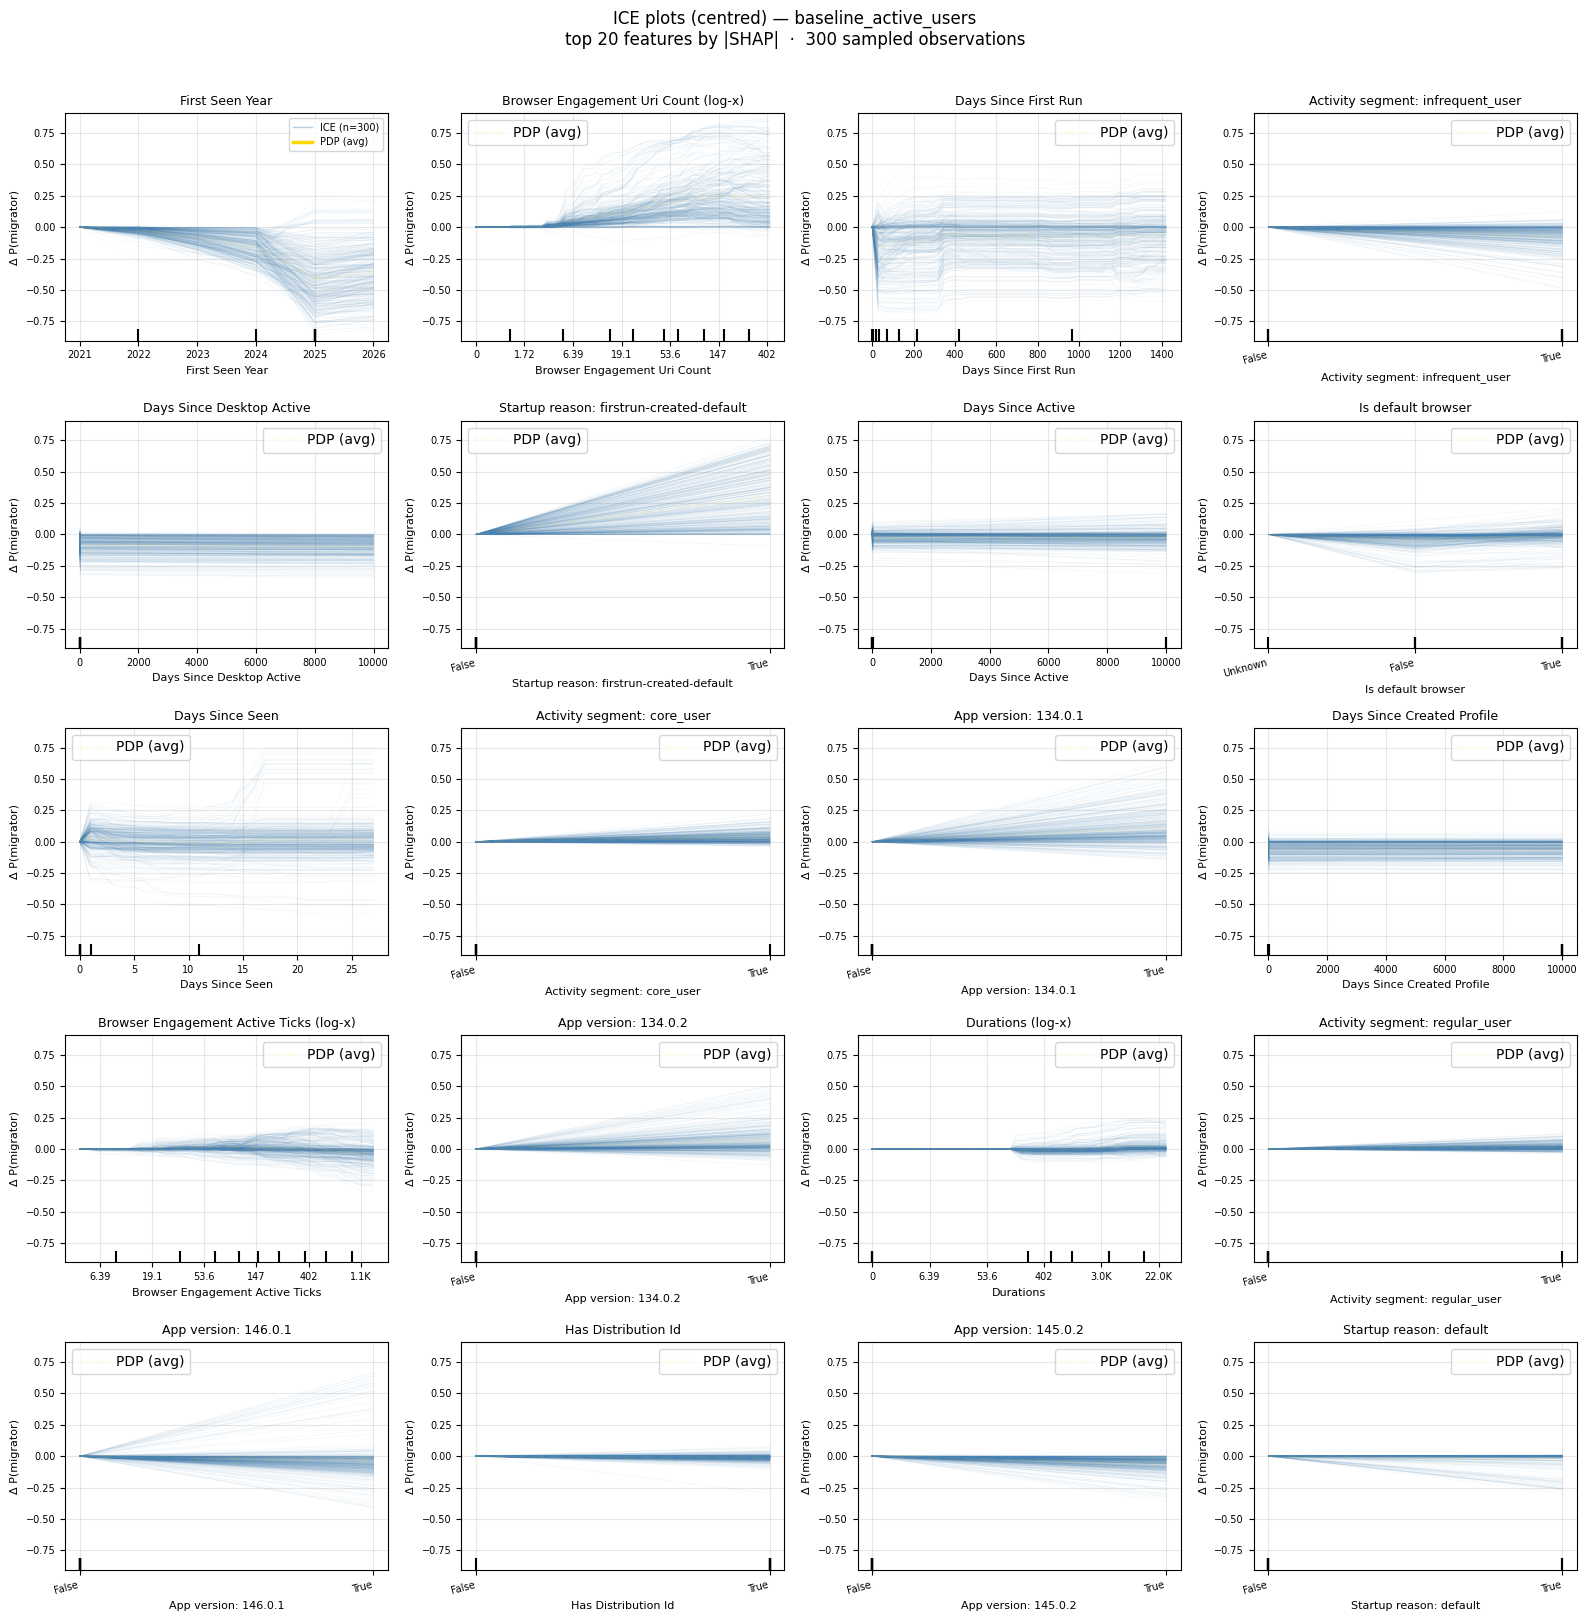

In [ ]:
# [ice-analysis]
# Individual Conditional Expectation (ICE) plots for the top 20 features by |SHAP|.
#
# Each thin line is one observation — it traces what the model predicts as that
# feature varies while its other features are held constant.  Lines are *centred*
# at the feature minimum so vertical position reflects the change in predicted
# probability (not the absolute level), making cross-feature comparisons easier.
# The thick yellow line is the average (== the PDP).
#
# Low alpha + centring keeps the grid readable even with many lines.

_ICE_N      = 300          # individuals to plot per panel (more → slower + busier)
_ICE_ALPHA  = 0.06         # opacity for each individual line
_GRID_RES   = 50           # grid points along the x-axis

_rng_ice = np.random.default_rng(RANDOM_STATE + 1)
_idx_ice = _rng_ice.choice(len(X_train), min(_ICE_N, len(X_train)), replace=False)
_X_ice   = X_train.iloc[_idx_ice]

fig, axes = plt.subplots(_nrows_p, _ncols_p, figsize=(_ncols_p * 4, _nrows_p * 3.2))
axes_flat = axes.flatten()

disp = PartialDependenceDisplay.from_estimator(
    xgb_model,
    _X_ice,
    features=_pdp_features,
    ax=axes_flat[:_n_pdp],
    kind='both',           # draws ICE lines + the PDP average
    centered=True,         # shift each ICE line to 0 at feature min → removes baseline noise
    grid_resolution=_GRID_RES,
    line_kw={'color': 'steelblue', 'alpha': _ICE_ALPHA, 'linewidth': 0.6},
    pd_line_kw={'color': 'gold', 'linewidth': 2.5, 'label': 'PDP (avg)'},
    n_jobs=-1,
)

# Apply human-readable labels, tick overrides, and clean up axes
for _i, (_ax, _feat) in enumerate(zip(axes_flat[:_n_pdp], _pdp_features)):
    _lbl = feat_labels.get(_feat, {})
    _ax.set_title(_lbl.get('title', _feat), fontsize=9)
    _ax.set_xlabel(_lbl.get('xlabel', 'feature value'), fontsize=8)
    _ax.set_ylabel('Δ P(migrator)', fontsize=8)
    _ax.tick_params(labelsize=7)
    if _lbl.get('is_log') and _lbl.get('tick_fmt'):
        _fn = _lbl['tick_fmt']
        _ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p, fn=_fn: fn(x)))
    elif _lbl.get('is_cat') and _lbl.get('tick_map'):
        _tm   = _lbl['tick_map']
        _vals = sorted(_tm.keys())
        _ax.set_xticks(_vals)
        _ax.set_xticklabels([_tm[v] for v in _vals], fontsize=7, rotation=15, ha='right')

# Legend on first panel only
axes_flat[0].legend(
    handles=[
        plt.Line2D([0], [0], color='steelblue', alpha=0.4, linewidth=1, label=f'ICE (n={_ICE_N})'),
        plt.Line2D([0], [0], color='gold',      linewidth=2.5,           label='PDP (avg)'),
    ],
    fontsize=7, loc='best', framealpha=0.8,
)

for _ax in axes_flat[_n_pdp:]:
    _ax.set_visible(False)

plt.suptitle(
    f'ICE plots (centred) — {EXTERNAL_TABLE.split(".")[-1]}\n'
    f'top {_n_pdp} features by |SHAP|  ·  {_ICE_N} sampled observations',
    y=1.01,
)
plt.tight_layout()
plt.show()

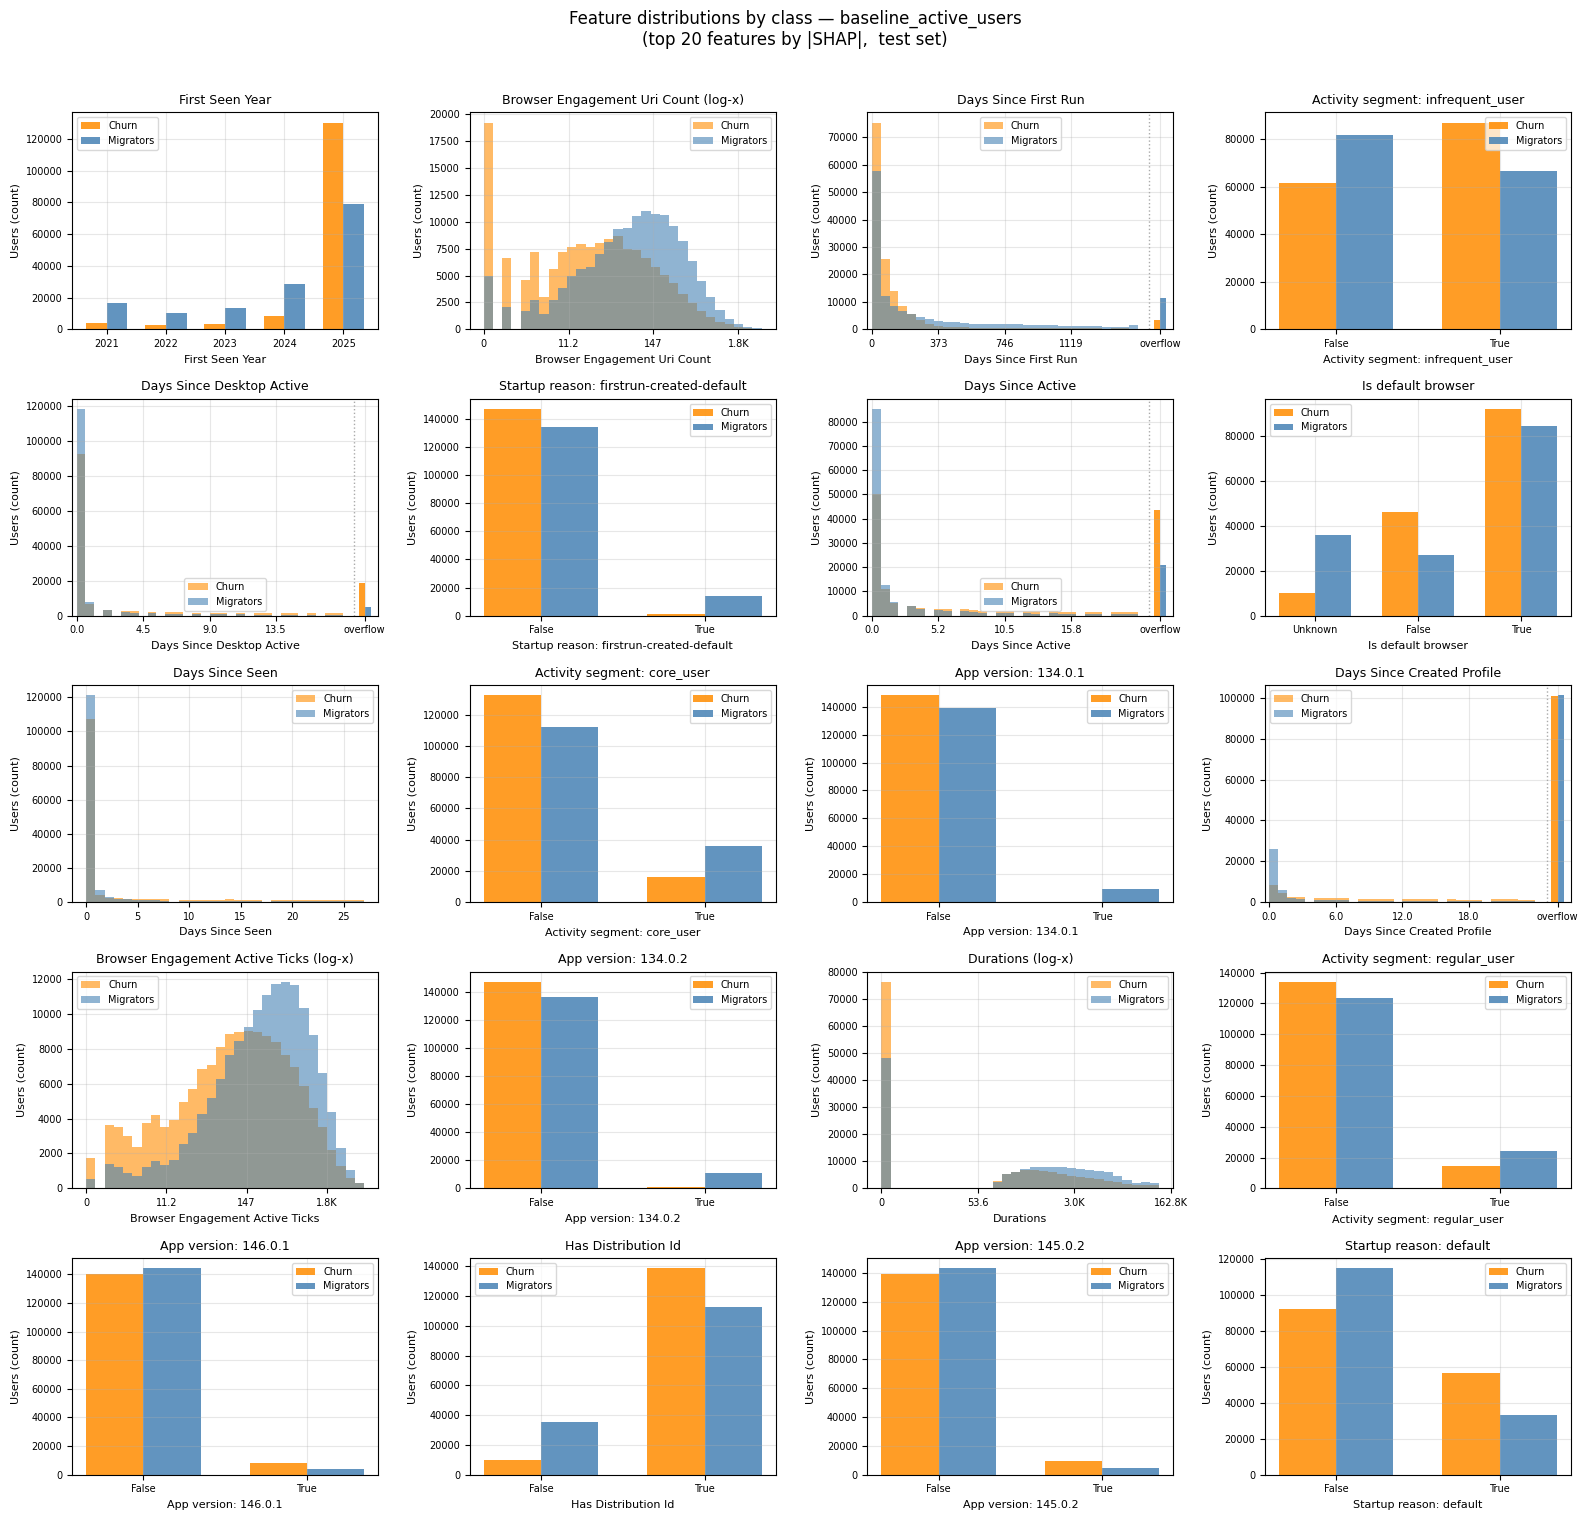

In [ ]:
# [feature-histograms]
# Histograms of the top 20 features by |SHAP|, split by class.
# Orange = Churn, blue = Migrators.
#
# Categorical / binary (≤ CATEG_THRESH unique values):
#   Side-by-side bars.  Categories with < CAT_MIN_FRAC of all observations are
#   dropped — they are genuinely absent, not truncated.
#
# Numeric with sentinel pattern (max >> bulk, e.g. days_since_* sentinel at 9999):
#   Main histogram covers 0 → p95 of (values < max), then a single side-by-side
#   "overflow" bar on the right aggregates all values beyond that cutoff.
#
# Numeric (no sentinel):
#   Bins computed on values ≤ p99 of the combined distribution.  The sub-1% tail
#   is silently excluded — it carries no visual information at this scale.

_CATEG_THRESH   = 10     # ≤ this many unique finite values → treat as categorical
_CAT_MIN_FRAC   = 0.01   # drop categorical bins with < this share of total obs
_N_BINS         = 30
_SENTINEL_RATIO = 2.5    # max / p95(values < max) threshold to trigger sentinel treatment
_TAIL_CLIP_PCT  = 99.9     # percentile used to clip the upper tail for standard numerics


def _sentinel_cutoff(arr_finite):
    """
    Returns (True, cutoff) when the distribution has a sentinel/outlier cluster
    packed at the max (e.g. fill value 9999).  cutoff = p95 of values < max.
    Returns (False, None) otherwise.
    """
    mx       = arr_finite.max()
    below    = arr_finite[arr_finite < mx]
    if len(below) < 20:
        return False, None
    p95 = np.percentile(below, 95)
    if p95 > 1 and mx / p95 > _SENTINEL_RATIO:
        return True, float(p95)
    return False, None


def _fmt_sentinel_tick(t, cutoff):
    """Scale-aware tick label for sentinel histogram main range."""
    if cutoff >= 100:
        return f'{t:.0f}'
    if cutoff >= 10:
        return f'{t:.1f}'
    return f'{t:.2g}'


_hist_features = _shap_importance.head(20).index.tolist()
_n_hist        = len(_hist_features)
_ncols_h       = 4
_nrows_h       = (_n_hist + _ncols_h - 1) // _ncols_h

fig, axes = plt.subplots(_nrows_h, _ncols_h, figsize=(_ncols_h * 4, _nrows_h * 3))
axes_flat = axes.flatten()

_mig_mask  = y_test.values == 1
_drop_mask = y_test.values == 0
_COL_DROP = 'darkorange'
_COL_MIG  = 'steelblue'

for _i, _feat in enumerate(_hist_features):
    _ax   = axes_flat[_i]
    _vals = X_test[_feat].values
    _vals_mig  = _vals[_mig_mask]
    _vals_drop = _vals[_drop_mask]
    _finite    = _vals[np.isfinite(_vals)]
    _n_unique  = len(np.unique(_finite))
    _lbl       = feat_labels.get(_feat, {})

    if _n_unique <= _CATEG_THRESH:
        # ── Categorical / binary: side-by-side bars ──────────────────────────
        _cats     = np.sort(np.unique(_finite))
        _cnt_drop = np.array([(_vals_drop == c).sum() for c in _cats])
        _cnt_mig  = np.array([(_vals_mig  == c).sum() for c in _cats])

        # Drop categories with negligible representation in both classes
        _min_count = _CAT_MIN_FRAC * len(_finite)
        _keep      = (_cnt_drop + _cnt_mig) >= _min_count
        _cats, _cnt_drop, _cnt_mig = _cats[_keep], _cnt_drop[_keep], _cnt_mig[_keep]

        _w = 0.35
        _x = np.arange(len(_cats))
        _ax.bar(_x - _w/2, _cnt_drop, width=_w, label='Churn',     color=_COL_DROP, alpha=0.85)
        _ax.bar(_x + _w/2, _cnt_mig,  width=_w, label='Migrators', color=_COL_MIG,  alpha=0.85)
        _ax.set_xticks(_x)
        _tm = _lbl.get('tick_map') or {}
        _ax.set_xticklabels(
            [_tm.get(c, str(int(c)) if c == int(c) else str(c)) for c in _cats],
            fontsize=7,
        )
        _ax.set_ylabel('Users (count)', fontsize=8)

    else:
        _has_sent, _cutoff = _sentinel_cutoff(_finite)

        if _has_sent:
            # ── Sentinel pattern: main histogram + overflow bar ───────────────
            _fd   = _vals_drop[np.isfinite(_vals_drop)]
            _fm   = _vals_mig[ np.isfinite(_vals_mig)]
            _bulk = _finite[_finite <= _cutoff]
            _bins = np.histogram_bin_edges(_bulk, bins=_N_BINS)
            _bw   = _bins[1] - _bins[0]

            _ax.hist(_fd, bins=_bins, alpha=0.6, color=_COL_DROP, label='Churn')
            _ax.hist(_fm, bins=_bins, alpha=0.6, color=_COL_MIG,  label='Migrators')

            _ov_drop = (_fd > _cutoff).sum()
            _ov_mig  = (_fm > _cutoff).sum()

            _ov_cx = _bins[-1] + 2.5 * _bw
            _ov_hw = 0.35 * _bw
            _ax.bar(_ov_cx - _ov_hw, _ov_drop, width=_ov_hw * 2, alpha=0.85, color=_COL_DROP)
            _ax.bar(_ov_cx + _ov_hw, _ov_mig,  width=_ov_hw * 2, alpha=0.85, color=_COL_MIG)

            _ax.axvline(_bins[-1] + 1.25 * _bw, color='#aaa', linestyle=':', linewidth=1)
            _ax.set_xlim(-0.5 * _bw, _ov_cx + 1.5 * _bw)

            _ticks_main = np.linspace(0, _cutoff, 5)[:-1]
            if _lbl.get('is_log') and _lbl.get('tick_fmt'):
                _tick_fn   = _lbl['tick_fmt']
                _tick_strs = [_tick_fn(t) for t in _ticks_main]
            else:
                _tick_strs = [_fmt_sentinel_tick(t, _cutoff) for t in _ticks_main]
            _ax.set_xticks(list(_ticks_main) + [_ov_cx])
            _ax.set_xticklabels(_tick_strs + ['overflow'], fontsize=7)

        else:
            # ── Standard numeric: clip tail at p99, no overflow bar ───────────
            # Values beyond the 99th percentile represent < 1% of users and add
            # no visual information at the histogram's scale.
            _p99  = np.percentile(_finite, _TAIL_CLIP_PCT)
            _bins = np.histogram_bin_edges(_finite[_finite <= _p99], bins=_N_BINS)
            _ax.hist(_vals_drop, bins=_bins, alpha=0.6, color=_COL_DROP, label='Churn')
            _ax.hist(_vals_mig,  bins=_bins, alpha=0.6, color=_COL_MIG,  label='Migrators')

            # Log features: K/M formatter + limit to 4 ticks so labels don't crowd
            if _lbl.get('is_log') and _lbl.get('tick_fmt'):
                _fn = _lbl['tick_fmt']
                _ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p, fn=_fn: fn(x)))
                _ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=4))

        _ax.set_ylabel('Users (count)', fontsize=8)

    _ax.set_title(_lbl.get('title', _feat), fontsize=9)
    _ax.set_xlabel(_lbl.get('xlabel', 'feature value'), fontsize=8)
    _ax.tick_params(labelsize=7)
    _ax.legend(fontsize=7, loc='best', framealpha=0.75)

for _ax in axes_flat[_n_hist:]:
    _ax.set_visible(False)

plt.suptitle(
    f'Feature distributions by class — {EXTERNAL_TABLE.split(".")[-1]}\n'
    f'(top {_n_hist} features by |SHAP|,  test set)',
    y=1.01,
)
plt.tight_layout()
plt.show()


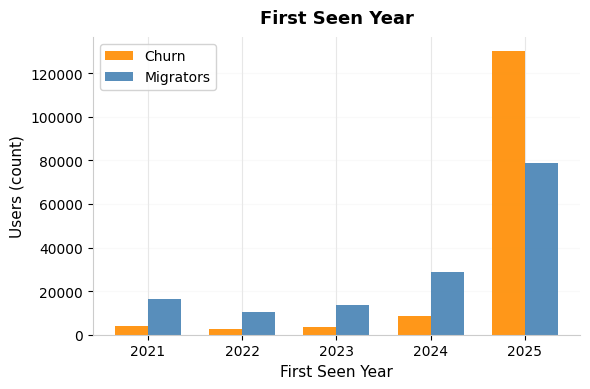

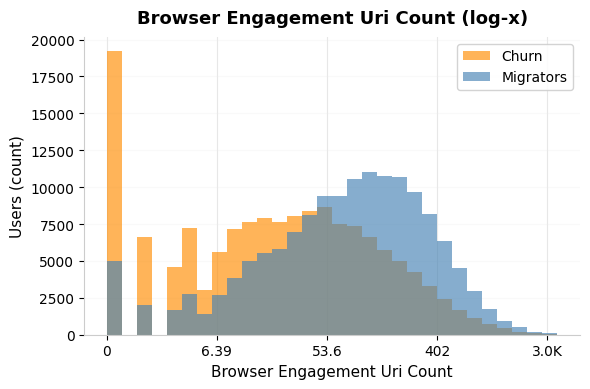

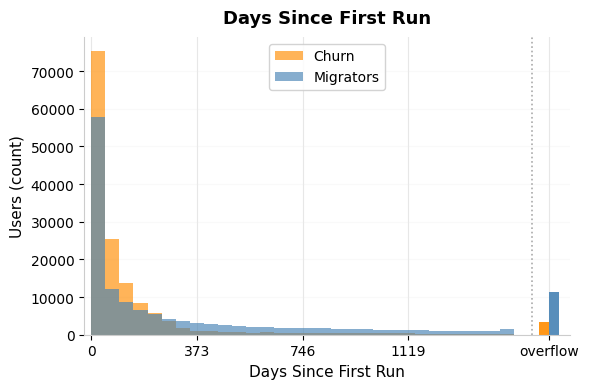

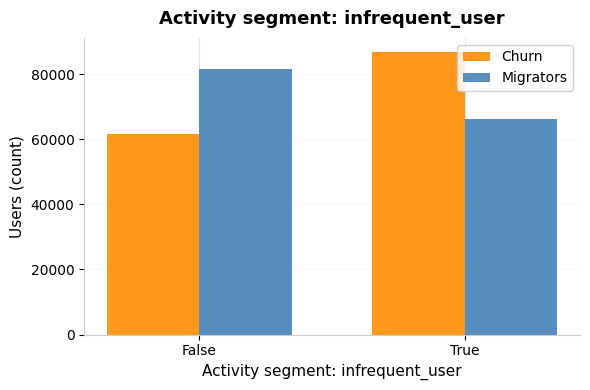

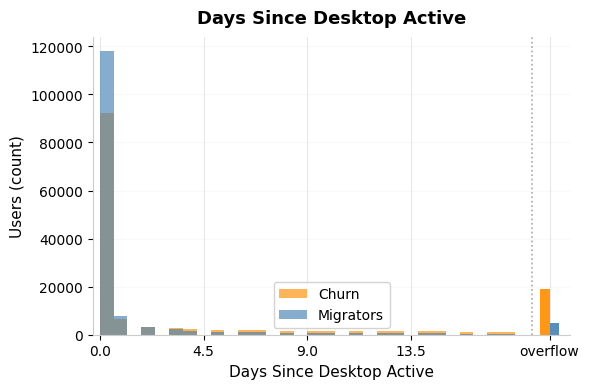

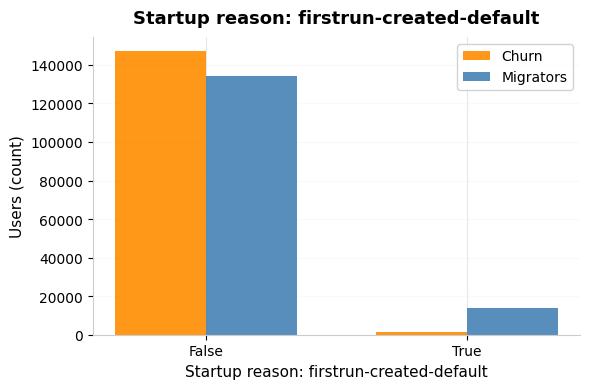

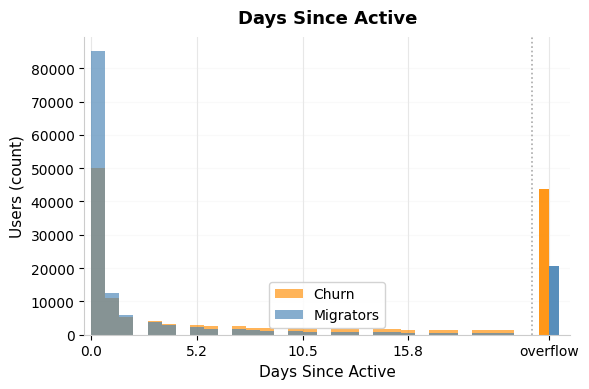

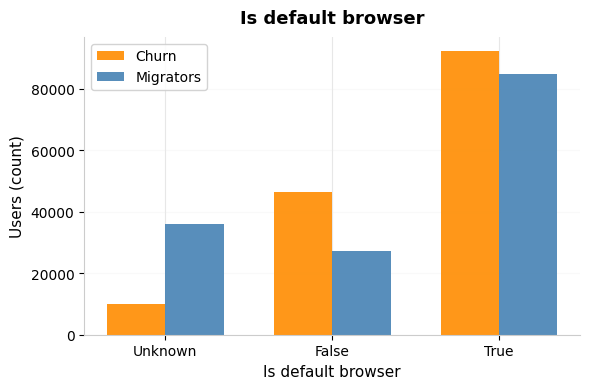

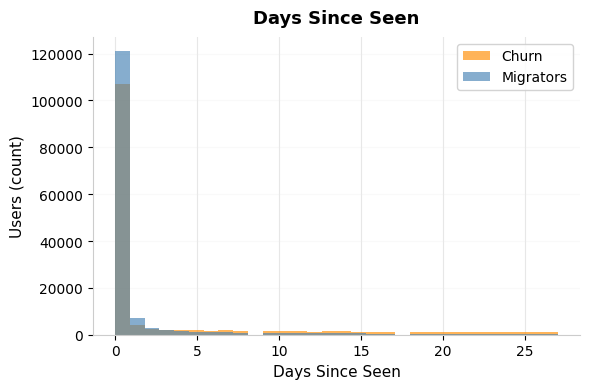

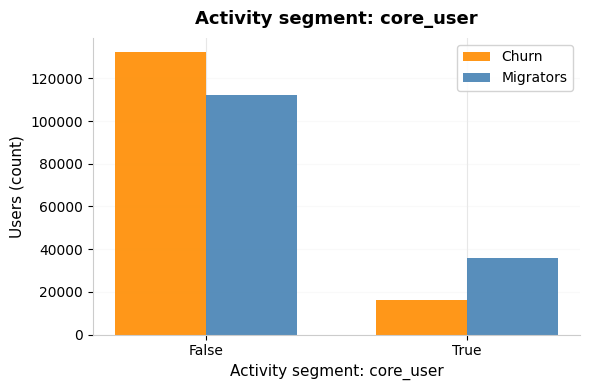

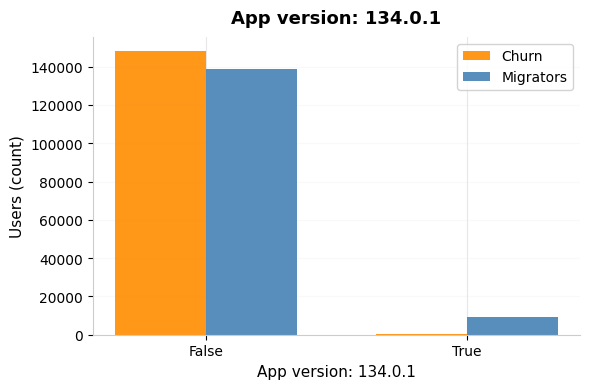

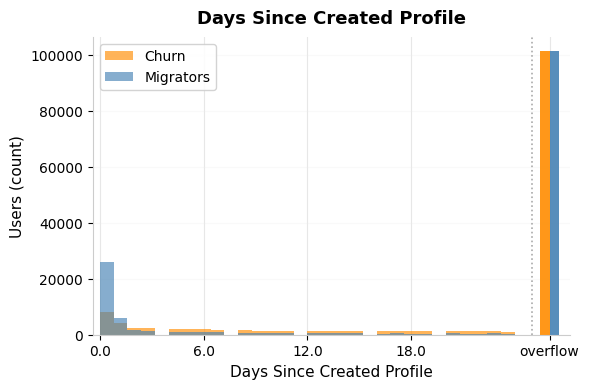

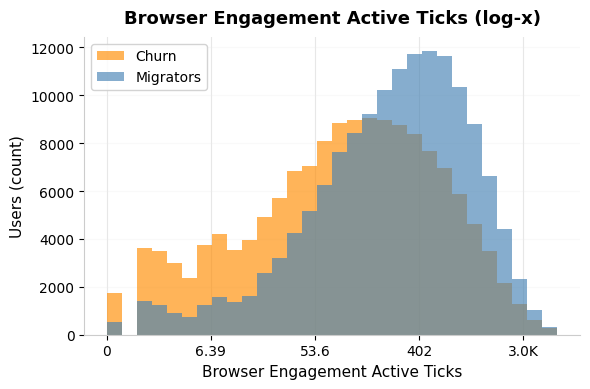

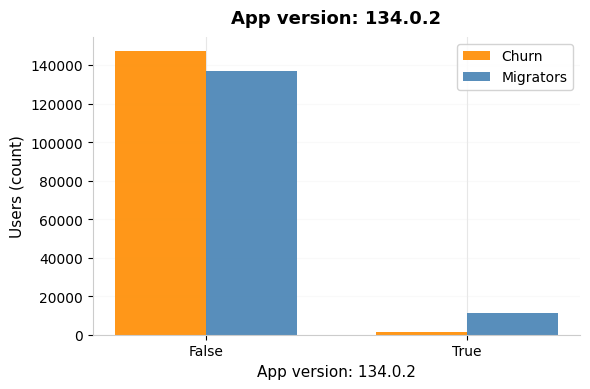

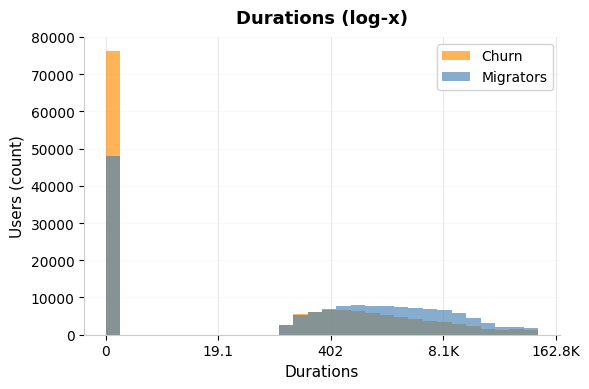

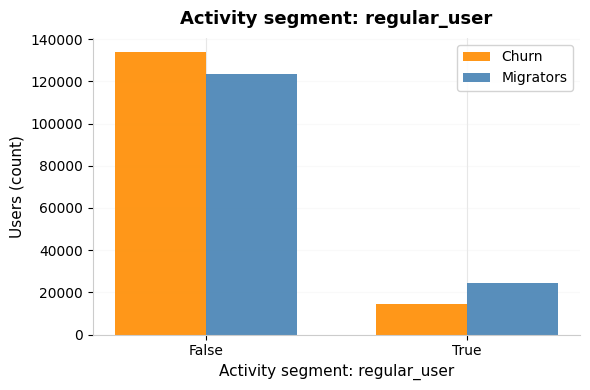

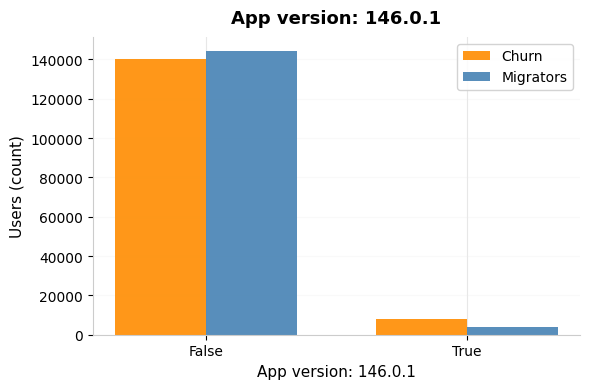

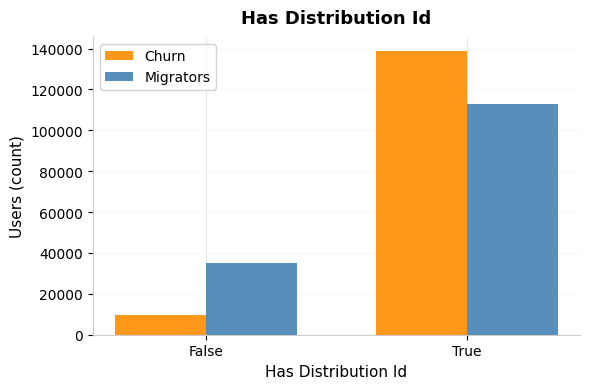

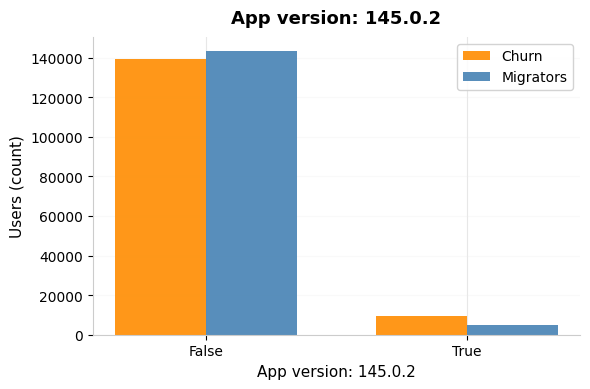

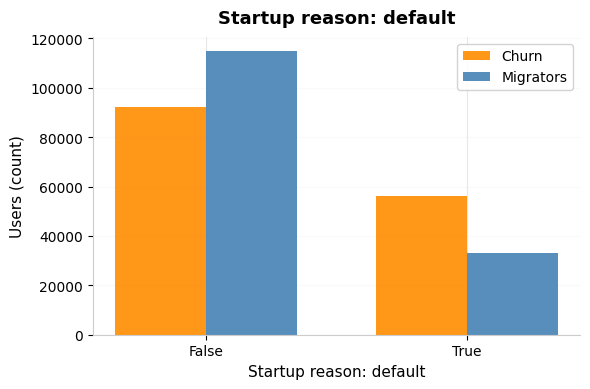

In [ ]:
# [feature-histograms-individual]
# Individual, report-ready histogram for each of the top-20 features by |SHAP|.
# Each figure is rendered at a consistent size with clean styling.
# To save to disk instead of displaying, set SAVE_FIGS = True and adjust OUT_DIR.

SAVE_FIGS = False
OUT_DIR   = Path('figures/feature_histograms')

if SAVE_FIGS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

_REPORT_COL_DROP = 'darkorange'
_REPORT_COL_MIG  = 'steelblue'
_FIG_W, _FIG_H   = 6, 4

for _feat in _hist_features:
    fig, _ax = plt.subplots(figsize=(_FIG_W, _FIG_H))

    _vals      = X_test[_feat].values
    _vals_mig  = _vals[_mig_mask]
    _vals_drop = _vals[_drop_mask]
    _finite    = _vals[np.isfinite(_vals)]
    _n_unique  = len(np.unique(_finite))
    _lbl       = feat_labels.get(_feat, {})

    if _n_unique <= _CATEG_THRESH:
        _cats     = np.sort(np.unique(_finite))
        _cnt_drop = np.array([(_vals_drop == c).sum() for c in _cats])
        _cnt_mig  = np.array([(_vals_mig  == c).sum() for c in _cats])

        _min_count = _CAT_MIN_FRAC * len(_finite)
        _keep      = (_cnt_drop + _cnt_mig) >= _min_count
        _cats, _cnt_drop, _cnt_mig = _cats[_keep], _cnt_drop[_keep], _cnt_mig[_keep]

        _w = 0.35
        _x = np.arange(len(_cats))
        _ax.bar(_x - _w/2, _cnt_drop, width=_w, label='Churn',     color=_REPORT_COL_DROP, alpha=0.9)
        _ax.bar(_x + _w/2, _cnt_mig,  width=_w, label='Migrators', color=_REPORT_COL_MIG,  alpha=0.9)
        _ax.set_xticks(_x)
        _tm = _lbl.get('tick_map') or {}
        _ax.set_xticklabels(
            [_tm.get(c, str(int(c)) if c == int(c) else str(c)) for c in _cats],
            fontsize=10,
        )

    else:
        _has_sent, _cutoff = _sentinel_cutoff(_finite)

        if _has_sent:
            _fd   = _vals_drop[np.isfinite(_vals_drop)]
            _fm   = _vals_mig[ np.isfinite(_vals_mig)]
            _bulk = _finite[_finite <= _cutoff]
            _bins = np.histogram_bin_edges(_bulk, bins=_N_BINS)
            _bw   = _bins[1] - _bins[0]

            _ax.hist(_fd, bins=_bins, alpha=0.65, color=_REPORT_COL_DROP, label='Churn',     linewidth=0)
            _ax.hist(_fm, bins=_bins, alpha=0.65, color=_REPORT_COL_MIG,  label='Migrators', linewidth=0)

            _ov_drop = (_fd > _cutoff).sum()
            _ov_mig  = (_fm > _cutoff).sum()
            _ov_cx   = _bins[-1] + 2.5 * _bw
            _ov_hw   = 0.35 * _bw
            _ax.bar(_ov_cx - _ov_hw, _ov_drop, width=_ov_hw * 2, alpha=0.9, color=_REPORT_COL_DROP)
            _ax.bar(_ov_cx + _ov_hw, _ov_mig,  width=_ov_hw * 2, alpha=0.9, color=_REPORT_COL_MIG)
            _ax.axvline(_bins[-1] + 1.25 * _bw, color='#aaa', linestyle=':', linewidth=1.2)
            _ax.set_xlim(-0.5 * _bw, _ov_cx + 1.5 * _bw)

            _ticks_main = np.linspace(0, _cutoff, 5)[:-1]
            if _lbl.get('is_log') and _lbl.get('tick_fmt'):
                _tick_strs = [_lbl['tick_fmt'](t) for t in _ticks_main]
            else:
                _tick_strs = [_fmt_sentinel_tick(t, _cutoff) for t in _ticks_main]
            _ax.set_xticks(list(_ticks_main) + [_ov_cx])
            _ax.set_xticklabels(_tick_strs + ['overflow'], fontsize=10)

        else:
            _p99  = np.percentile(_finite, _TAIL_CLIP_PCT)
            _bins = np.histogram_bin_edges(_finite[_finite <= _p99], bins=_N_BINS)
            _ax.hist(_vals_drop, bins=_bins, alpha=0.65, color=_REPORT_COL_DROP, label='Churn',     linewidth=0)
            _ax.hist(_vals_mig,  bins=_bins, alpha=0.65, color=_REPORT_COL_MIG,  label='Migrators', linewidth=0)

            if _lbl.get('is_log') and _lbl.get('tick_fmt'):
                _fn = _lbl['tick_fmt']
                _ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p, fn=_fn: fn(x)))
                _ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))

    # ── Styling ──────────────────────────────────────────────────────────────
    _ax.set_title(_lbl.get('title', _feat), fontsize=13, fontweight='bold', pad=10)
    _ax.set_xlabel(_lbl.get('xlabel', 'feature value'), fontsize=11)
    _ax.set_ylabel('Users (count)', fontsize=11)
    _ax.tick_params(labelsize=10)
    _ax.legend(fontsize=10, framealpha=0.85, edgecolor='#ccc')

    _ax.spines['top'].set_visible(False)
    _ax.spines['right'].set_visible(False)
    _ax.spines['left'].set_color('#ccc')
    _ax.spines['bottom'].set_color('#ccc')
    _ax.set_axisbelow(True)
    _ax.yaxis.grid(True, color='#ececec', linewidth=0.8)

    fig.tight_layout()

    if SAVE_FIGS:
        _out = OUT_DIR / f'{_feat}.png'
        fig.savefig(_out, dpi=150, bbox_inches='tight')
        print(f'Saved {_out}')

    plt.show()
    plt.close(fig)


In [24]:
# [decision-tree]
# Fits a shallow decision tree on the top-N XGBoost features.
# Also searches over 1-, 2-, and 3-feature subsets of the top SEARCH_POOL_SIZE
# features to find the simplest interpretable model with meaningful AUC.
# "Simplest" = fewest features that still exceed SMOKING_FEW_AUC; falls back
# to the best 3-feature result if none of the 1- or 2-feature models qualify.

_top_features = _shap_importance.head(TOP_N_FEATURES).index.tolist()
print(f'Top {TOP_N_FEATURES} features: {_top_features}\n')

# --- Full top-N tree ---
_dt = DecisionTreeClassifier(
    max_depth=TREE_MAX_DEPTH, class_weight='balanced', random_state=RANDOM_STATE
)
_dt.fit(X_train[_top_features], y_train)
_dt_auc_full = roc_auc_score(y_test, _dt.predict_proba(X_test[_top_features])[:, 1])
print(f'Decision tree (top {TOP_N_FEATURES} features, depth={TREE_MAX_DEPTH}): AUC={_dt_auc_full:.4f}')

# --- Greedy few-feature search over top SEARCH_POOL_SIZE ---
_search_pool = _top_features[:min(SEARCH_POOL_SIZE, len(_top_features))]
_results = {}  # (n_features, features_tuple) -> auc

def _dt_auc(feats):
    _m = DecisionTreeClassifier(
        max_depth=TREE_MAX_DEPTH, class_weight='balanced', random_state=RANDOM_STATE
    )
    _m.fit(X_train[list(feats)], y_train)
    return roc_auc_score(y_test, _m.predict_proba(X_test[list(feats)])[:, 1])

for _f in _search_pool:
    _results[(1, (_f,))] = _dt_auc([_f])
for _f1, _f2 in combinations(_search_pool, 2):
    _results[(2, (_f1, _f2))] = _dt_auc([_f1, _f2])
for _f1, _f2, _f3 in combinations(_search_pool, 3):
    _results[(3, (_f1, _f2, _f3))] = _dt_auc([_f1, _f2, _f3])

_best_1 = max(((k, v) for k, v in _results.items() if k[0] == 1), key=lambda x: x[1])
_best_2 = max(((k, v) for k, v in _results.items() if k[0] == 2), key=lambda x: x[1])
_best_3 = max(((k, v) for k, v in _results.items() if k[0] == 3), key=lambda x: x[1])

_dt_auc_1f, _best_1f = _best_1[1], list(_best_1[0][1])
_dt_auc_2f, _best_2f = _best_2[1], list(_best_2[0][1])
_dt_auc_3f, _best_3f = _best_3[1], list(_best_3[0][1])

print(f'\n--- Best few-feature decision trees (depth={TREE_MAX_DEPTH}) ---')
print(f'1 feature:  AUC={_dt_auc_1f:.4f}  {_best_1f}')
print(f'2 features: AUC={_dt_auc_2f:.4f}  {_best_2f}')
print(f'3 features: AUC={_dt_auc_3f:.4f}  {_best_3f}')

# Pick the simplest model (fewest features) that exceeds the smoking-gun threshold.
# Fall back to the best 3-feature result if none qualify.
if _dt_auc_1f >= SMOKING_FEW_AUC:
    _best_few_feats, _best_few_auc = _best_1f, _dt_auc_1f
elif _dt_auc_2f >= SMOKING_FEW_AUC:
    _best_few_feats, _best_few_auc = _best_2f, _dt_auc_2f
else:
    _best_few_feats, _best_few_auc = _best_3f, _dt_auc_3f

print(f'\n→ Simplest model for verdict: {len(_best_few_feats)} feature(s)  '
      f'AUC={_best_few_auc:.4f}  {_best_few_feats}')

# Print rules for the chosen few-feature tree
_dt_few = DecisionTreeClassifier(
    max_depth=TREE_MAX_DEPTH, class_weight='balanced', random_state=RANDOM_STATE
)
_dt_few.fit(X_train[_best_few_feats], y_train)

print(f'\n--- Decision tree rules ({len(_best_few_feats)} features) ---')
print(export_text(_dt_few, feature_names=_best_few_feats))

print(f'--- Decision tree rules (top {TOP_N_FEATURES} features) ---')
print(export_text(_dt, feature_names=_top_features))


Top 10 features: ['first_seen_year', 'log_browser_engagement_uri_count', 'days_since_first_run', 'activity_seg_infrequent_user', 'days_since_desktop_active', 'startup_firstrun-created-default', 'days_since_active', 'is_default_browser_f', 'days_since_seen', 'activity_seg_core_user']

Decision tree (top 10 features, depth=4): AUC=0.8365

--- Best few-feature decision trees (depth=4) ---
1 feature:  AUC=0.7311  ['days_since_first_run']
2 features: AUC=0.7892  ['log_browser_engagement_uri_count', 'days_since_first_run']
3 features: AUC=0.8223  ['first_seen_year', 'log_browser_engagement_uri_count', 'days_since_first_run']

→ Simplest model for verdict: 1 feature(s)  AUC=0.7311  ['days_since_first_run']

--- Decision tree rules (1 features) ---
|--- days_since_first_run <= 297.50
|   |--- days_since_first_run <= 1.50
|   |   |--- days_since_first_run <= 0.50
|   |   |   |--- class: 1
|   |   |--- days_since_first_run >  0.50
|   |   |   |--- class: 1
|   |--- days_since_first_run >  1.50
|

In [25]:
# [smoking-gun]
# Thresholds are set in # [config]: WEAK_AUC, SMOKING_AUC, SMOKING_FEW_AUC.

_src = EXTERNAL_TABLE.split('.')[-1]
_top3_names = ', '.join(_shap_importance.head(3).index.tolist())

print('=' * 65)
print(f'VERDICT: {_src}')
print('=' * 65)
print(f'Full XGBoost AUC:                   {_full_model_auc:.4f}')
print(f'Decision tree AUC (top {TOP_N_FEATURES} features):   {_dt_auc_full:.4f}')
print(f'Best 1-feature AUC:                 {_dt_auc_1f:.4f}  {_best_1f}')
print(f'Best 2-feature AUC:                 {_dt_auc_2f:.4f}  {_best_2f}')
print(f'Best 3-feature AUC:                 {_dt_auc_3f:.4f}  {_best_3f}')
print(f'Simplest model for verdict:         {_best_few_auc:.4f}  {_best_few_feats}')
print()

if _full_model_auc >= SMOKING_AUC and _best_few_auc >= SMOKING_FEW_AUC:
    print('SMOKING GUN')
    print()
    print(
        f'Strong, interpretable signal found in {_src}. '
        f'Using only {len(_best_few_feats)} feature(s) '
        f'({", ".join(_best_few_feats)}), a simple decision tree reaches '
        f'AUC={_best_few_auc:.3f}. The full XGBoost model reaches '
        f'AUC={_full_model_auc:.3f}. '
        f'These features are strong candidates for retention targeting and '
        f'warrant deeper investigation.'
    )
elif _full_model_auc >= WEAK_AUC:
    print('WEAK SIGNAL')
    print()
    print(
        f'Moderate signal in {_src} (full model AUC={_full_model_auc:.3f}), '
        f'but the best {len(_best_few_feats)}-feature model only reaches '
        f'AUC={_best_few_auc:.3f} — not strong enough to target users reliably alone. '
        f'Top features by SHAP importance: {_top3_names}. '
        f'Worth combining with signals from other tables, but not a smoking gun on its own.'
    )
else:
    print('NO SIGNAL')
    print()
    print(
        f'No meaningful predictive signal in {_src} '
        f'(full model AUC={_full_model_auc:.3f}, near chance). '
        f'The features in this table do not distinguish migrators from dropoffs. '
        f'Move on to the next table.'
    )

print('=' * 65)


VERDICT: baseline_active_users
Full XGBoost AUC:                   0.8844
Decision tree AUC (top 10 features):   0.8365
Best 1-feature AUC:                 0.7311  ['days_since_first_run']
Best 2-feature AUC:                 0.7892  ['log_browser_engagement_uri_count', 'days_since_first_run']
Best 3-feature AUC:                 0.8223  ['first_seen_year', 'log_browser_engagement_uri_count', 'days_since_first_run']
Simplest model for verdict:         0.7311  ['days_since_first_run']

SMOKING GUN

Strong, interpretable signal found in baseline_active_users. Using only 1 feature(s) (days_since_first_run), a simple decision tree reaches AUC=0.731. The full XGBoost model reaches AUC=0.884. These features are strong candidates for retention targeting and warrant deeper investigation.


In [ ]:
# [new-end-cell]
print("hello from end")
